# Foci detector benchmark — DnaN-mCherry / ImuB-GFP

Phase-0 harness. Runs head-to-head comparisons of foci-detection approaches on a real MycoPrep run
directory before we commit to a v1 implementation inside `src/mycoprep/core/fluorescence/`.

**Methods compared:**
- *Classical baseline pack*: DoG, LoG, trackpy
- *Normalisation pack*: Top-hat → DoG, Gaussian-low-pass-ratio → DoG, BaSiC flatfield → DoG
- *Bacterial-specific*: Wang et al. 2015 bacteroidal-bg + 2D Gaussian fit
- *Deep learning*: Spotiflow (pretrained `general`)

**Inputs:** a MycoPrep run directory containing segmented per-well TIFF hyperstacks (mask is the last channel).

**Outputs (written to `notebooks/benchmark_foci_outputs/<run_name>__<timestamp>/`):**
- `overlays/<well>__fov<idx>__<channel>.png` — per-FOV side-by-side overlays
- `per_focus.parquet` — long-form (detector, well, fov, channel, y, x, sigma, intensity, snr, cell_label, condition)
- `per_cell_counts.parquet` — long-form (detector, well, fov, channel, cell_label, foci_count)
- `agreement_heatmap.png`, `runtime_bar.png`, `count_distributions_<channel>.png`
- `flatfield_<channel>.png` if BaSiC ran

---

## Install (one-off)

```bash
pip install trackpy spotiflow lmfit
```

The three above install on Python 3.10–3.13 with no compiler. `gaussian_norm_dog` is the
basicpy-free shading-correction option and uses only `scipy.ndimage` (already a project dep).

**BaSiC (optional, currently wedged on Python 3.13):** `pip install basicpy` pins
`scipy<1.13` and `jaxlib<=0.4.23`, neither of which has Python 3.13 wheels — so installing
basicpy on Python 3.13 falls back to a source build that needs `gfortran`. If you need
BaSiC's darkfield estimation specifically, the simplest workaround is a sidecar Python 3.11/3.12
venv, or wait for upstream basicpy to ship 3.13 wheels. Otherwise leave `basic_dog` out of
`ENABLED_DETECTORS` and use `gaussian_norm_dog` and `tophat_dog` for the normalisation comparison.

Detectors are lazy-imported — drop any key out of `ENABLED_DETECTORS` and the rest still runs.
Spotiflow downloads a pretrained model on first call.

In [1]:
from __future__ import annotations

import sys, time, json
from datetime import datetime
from pathlib import Path

# Repo root is the directory containing pyproject.toml above this notebook.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Could not locate repo root (expected pyproject.toml above this notebook).")

for p in (REPO_ROOT, REPO_ROOT / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.benchmark_foci import data as bf_data
from scripts.benchmark_foci import metrics as bf_metrics
from scripts.benchmark_foci import viz as bf_viz
from scripts.benchmark_foci._types import DetectorOpts
from scripts.benchmark_foci import detectors as bf_detectors
print(f"Repo root: {REPO_ROOT}")

Repo root: /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Timothy de Wet/Science/Admin/2026/Code/MycoPrep/.claude/worktrees/wonderful-pike-259685


## Configure

Fill in `RUN_DIR` with a path to a MycoPrep run that has segmented per-well hyperstacks.

- `ENABLED_DETECTORS` — short keys from `bf_detectors.REGISTRY`. The default omits `basic_dog`
  because basicpy doesn't currently install cleanly on Python 3.13 (see install note above).
- `N_FOVS_PER_CONDITION` — capped at 3 by default. The benchmark also enforces `MAX_TOTAL_FOVS`.
- `OPTS` — detection knobs. The same `DetectorOpts` is passed to every detector; each
  ignores fields that don't apply to it.

In [2]:
# ───────────────────────── EDIT THESE ─────────────────────────
RUN_DIR = Path("/Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/Test")    # ← point at a real run
ENABLED_DETECTORS = [
    "dog",
    "log",
    "trackpy",
    "tophat_dog",
    "gaussian_norm_dog",
    # "basic_dog",            # uncomment once basicpy supports Python 3.13
    "bacteroidal",
    "spotiflow",
]
N_FOVS_PER_CONDITION = 3
MAX_TOTAL_FOVS = 12
RNG_SEED = 0

OPTS = DetectorOpts(
    min_sigma=1.0,
    max_sigma=3.5,
    num_sigma=6,
    threshold=0.02,
    snr_min=3.0,
    refine=True,
    refine_window=4,
    tophat_radius_px=5,
    trackpy_diameter_px=7,
)
# ──────────────────────────────────────────────────────────────

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = RUN_DIR.parent / "foci_benchmark_outputs" / f"{RUN_DIR.name}__{TIMESTAMP}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "overlays").mkdir(exist_ok=True)
print(f"Outputs → {OUT_DIR}")

Outputs → /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/foci_benchmark_outputs/Test__20260516_094437


## Load FOVs

Discovers per-well TIFFs, samples up to `N_FOVS_PER_CONDITION` FOVs per condition class
(capped at `MAX_TOTAL_FOVS`), returns a list of `FovBundle`s.

In [3]:
bundles = bf_data.load_run(
    RUN_DIR,
    n_per_condition=N_FOVS_PER_CONDITION,
    max_total=MAX_TOTAL_FOVS,
    rng_seed=RNG_SEED,
)
print(f"Loaded {len(bundles)} FOVs from {RUN_DIR}")
if not bundles:
    raise RuntimeError("No FOVs loaded. Check RUN_DIR.")

rows = []
for b in bundles:
    rows.append({
        "well": b.well,
        "fov": b.fov_index,
        "n_cells": b.n_cells,
        "channels": ",".join(b.channel_names),
        "fluorescence_channels": [b.channel_names[i] for i in b.fluorescence_channel_indices],
        "condition": b.condition_fields.get("condition_label", ""),
        "reporter": b.condition_fields.get("reporter", ""),
    })
inventory_df = pd.DataFrame(rows)
inventory_df.to_csv(OUT_DIR / "inventory.csv", index=False)
inventory_df

Loaded 3 FOVs from /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/Test


,well,fov,n_cells,channels,fluorescence_channels,condition,reporter
0,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,5,188,"Bright,mCher,EGFP","[mCher, EGFP]",1X_MMC,DnaN-mCherry_ImuB-GFP
1,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,9,244,"Bright,mCher,EGFP","[mCher, EGFP]",1X_MMC,DnaN-mCherry_ImuB-GFP
2,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,6,263,"Bright,mCher,EGFP","[mCher, EGFP]",1X_MMC,DnaN-mCherry_ImuB-GFP


## Build detector instances

Instantiate one of each enabled detector. BaSiC needs a per-channel run-wide fit before it can detect, so we do that next.

In [4]:
detector_instances = {}
for key in ENABLED_DETECTORS:
    if key not in bf_detectors.REGISTRY:
        print(f"  WARN: unknown detector key {key!r}, skipping")
        continue
    detector_instances[key] = bf_detectors.REGISTRY[key]()
print("Detectors instantiated:", list(detector_instances))

Detectors instantiated: ['dog', 'log', 'trackpy', 'tophat_dog', 'gaussian_norm_dog', 'bacteroidal', 'spotiflow']


## Fit BaSiC (per fluorescence channel) — only if `basic_dog` is enabled

Collects all FOVs from all loaded wells per channel, then calls `BaSiC.fit`.
Saves a flatfield preview to QC the result. Skipped automatically when `basic_dog`
isn't in `ENABLED_DETECTORS` (e.g. on Python 3.13 where basicpy currently can't install).

In [5]:
if "basic_dog" in detector_instances:
    canonical = bundles[0]
    run_stack: dict[int, list[np.ndarray]] = {ci: [] for ci in canonical.fluorescence_channel_indices}
    for b in bundles:
        for ci in b.fluorescence_channel_indices:
            if ci in run_stack:
                run_stack[ci].append(b.image_channels[ci])
    n_total = sum(len(v) for v in run_stack.values())
    print(f"Fitting BaSiC on {len(run_stack)} channel(s), {n_total} FOV-channel images total ...")
    t0 = time.perf_counter()
    detector_instances["basic_dog"].fit(run_stack)
    print(f"  done in {time.perf_counter() - t0:.1f} s")

    basic = detector_instances["basic_dog"]
    for ci, flat in basic.flatfields.items():
        dark = basic.darkfields.get(ci, np.zeros_like(flat))
        raw = run_stack[ci][0]
        corrected = basic.correct(raw, channel_index=ci)
        cname = canonical.channel_names[ci]
        fig = bf_viz.flatfield_preview(raw, flat, dark, corrected,
                                       title=f"BaSiC correction — {cname}")
        fig.savefig(OUT_DIR / f"flatfield_{cname}.png", dpi=120, bbox_inches="tight")
        plt.show()
else:
    print("BaSiC not enabled — skipping fit (gaussian_norm_dog / tophat_dog handle normalisation)")

BaSiC not enabled — skipping fit (gaussian_norm_dog / tophat_dog handle normalisation)


## Run all detectors on all selected FOVs

Iterates `(FOV, fluorescence channel, detector)`, times each call, records foci. Long-form parquets written at the end.

In [6]:
per_focus_rows: list[dict] = []
per_cell_count_dfs: list[pd.DataFrame] = []
runtime_rows: list[dict] = []
foci_cache: dict[tuple, dict] = {}      # (well, fov, channel) -> {detector: list[Focus]}

for b in bundles:
    cond = b.condition_fields.get("condition_label", "")
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        image = b.image_channels[ci]
        key = (b.well, b.fov_index, cname)
        foci_cache[key] = {}
        for det_name, det in detector_instances.items():
            t0 = time.perf_counter()
            try:
                if det_name == "basic_dog":
                    foci = det.detect(image, labeled_mask=b.labeled_mask, opts=OPTS, channel_index=ci)
                else:
                    foci = det.detect(image, labeled_mask=b.labeled_mask, opts=OPTS)
            except Exception as exc:  # noqa: BLE001
                print(f"  {det_name} failed on {b.well} FOV{b.fov_index} {cname}: {exc}")
                foci = []
            elapsed = time.perf_counter() - t0
            foci_cache[key][det_name] = foci

            per_focus_rows.extend(bf_metrics.foci_to_records(
                foci, detector=det_name, well=b.well, fov_index=b.fov_index,
                channel=cname, condition_label=cond,
            ))
            runtime_rows.append({
                "detector": det_name, "well": b.well, "fov_index": b.fov_index,
                "channel": cname, "seconds": elapsed, "n_foci": len(foci),
            })
        cell_df_per_fov = pd.concat([
            bf_metrics.count_per_cell(
                pd.DataFrame(per_focus_rows),
                detector=det_name, well=b.well, fov_index=b.fov_index,
                channel=cname, n_cells=b.n_cells,
            )
            for det_name in detector_instances
        ], ignore_index=True)
        cell_df_per_fov["condition_label"] = cond
        per_cell_count_dfs.append(cell_df_per_fov)

per_focus_df = pd.DataFrame(per_focus_rows)
per_cell_df = pd.concat(per_cell_count_dfs, ignore_index=True) if per_cell_count_dfs else pd.DataFrame()
runtime_df = pd.DataFrame(runtime_rows)

per_focus_df.to_parquet(OUT_DIR / "per_focus.parquet", index=False)
per_cell_df.to_parquet(OUT_DIR / "per_cell_counts.parquet", index=False)
runtime_df.to_csv(OUT_DIR / "runtime.csv", index=False)
print(f"Wrote {len(per_focus_df)} foci rows, {len(per_cell_df)} per-cell rows.")
per_focus_df.head()

/Users/timdewet/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:spotiflow.model.spotiflow:Loading pretrained model: general
Wrote 39934 foci rows, 9730 per-cell rows.


,detector,well,fov_index,channel,condition_label,y,x,sigma,intensity,snr,cell_label
0,dog,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,5,mCher,1X_MMC,451.916153,1753.237874,2.288653,2700.361863,12.740806,0
1,dog,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,5,mCher,1X_MMC,1196.175131,1483.305003,2.321111,2921.213188,11.205227,0
2,dog,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,5,mCher,1X_MMC,1227.168918,1471.802638,2.155195,2745.372896,8.596149,0
3,dog,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,5,mCher,1X_MMC,419.646607,849.922201,2.195528,2747.469948,9.602294,0
4,dog,6hrs__DnaN-mCherry_ImuB-GFP__1X_MMC__R1_focused,5,mCher,1X_MMC,350.138261,1155.737826,2.768042,2157.470067,7.927878,0


## Per-FOV overlay grids

One PNG per (well, FOV, channel) with one panel per detector. Cell outlines in cyan, foci circled in orange (cell-internal) or red (outside any cell).

In [7]:
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        fig = bf_viz.overlay_grid(
            b.image_channels[ci],
            b.labeled_mask,
            foci_by_detector=foci_cache.get(key, {}),
            title=f"{b.well}  FOV {b.fov_index}  {cname}  (cond={b.condition_fields.get('condition_label','')})",
        )
        out = OUT_DIR / "overlays" / f"{b.well}__fov{b.fov_index:03d}__{cname}.png"
        fig.savefig(out, dpi=120, bbox_inches="tight")
        plt.close(fig)
print(f"Saved {sum(len(b.fluorescence_channel_indices) for b in bundles)} overlay PNGs to {OUT_DIR / 'overlays'}")

Saved 6 overlay PNGs to /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/foci_benchmark_outputs/Test__20260516_094437/overlays


## Foci-count distributions

Per-detector strip plots of foci counts per cell, split by condition class. The biological sanity check (Warner et al. 2022): ImuB foci/cell should be ≈ 0 in undamaged conditions and > 0 under DNA damage (MMC / UV).

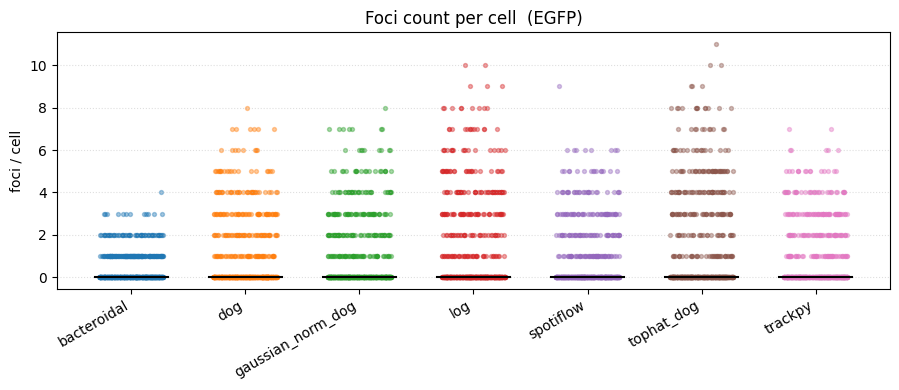

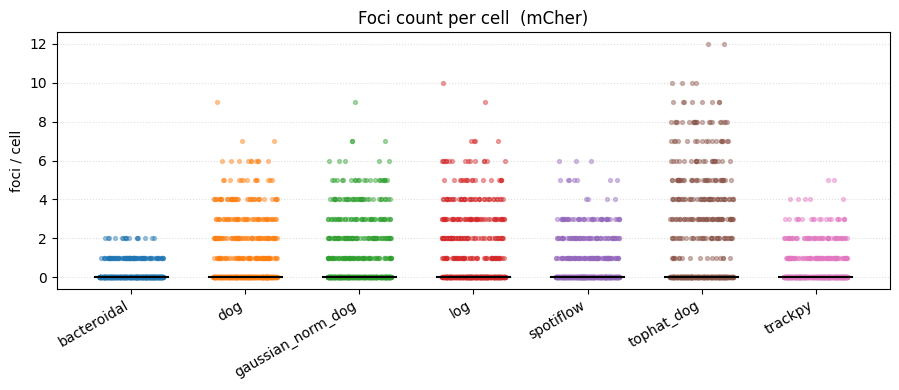

In [8]:
if not per_cell_df.empty:
    for cname in sorted(per_cell_df["channel"].unique()):
        fig = bf_viz.count_distributions(per_cell_df, channel=cname)
        fig.savefig(OUT_DIR / f"count_distributions_{cname}.png", dpi=120, bbox_inches="tight")
        plt.show()
else:
    print("No per-cell data to plot.")

## Detector agreement heatmap

Mean pairwise Jaccard across all (well, FOV, channel) groups: matched foci / (matched + unmatched-A + unmatched-B), with a 1.5 px match tolerance. Clusters of high agreement indicate detectors that are essentially measuring the same thing.

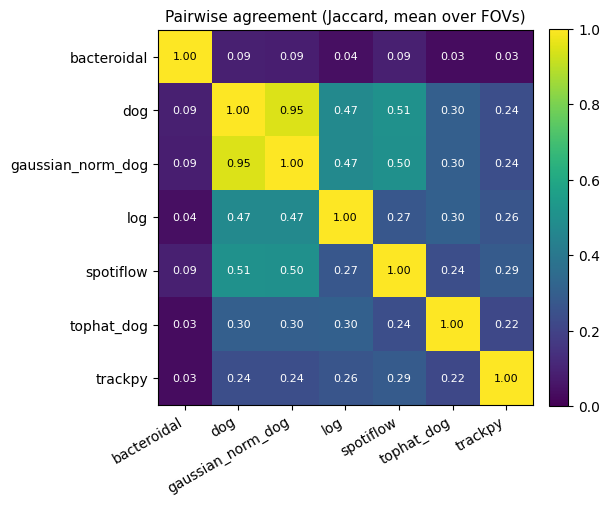

Agreement matrix written.


In [9]:
if not per_focus_df.empty:
    detectors_in_run = sorted(per_focus_df["detector"].unique())
    agreement = bf_metrics.agreement_matrix(per_focus_df, detectors=detectors_in_run, tol_px=1.5)
    fig = bf_viz.agreement_heatmap(agreement)
    fig.savefig(OUT_DIR / "agreement_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()
    agreement.to_csv(OUT_DIR / "agreement_matrix.csv")
    print("Agreement matrix written.")
else:
    print("No foci recorded — skipping agreement heatmap.")

cell_snr_min=6.0: foci kept (before → after)
           bacteroidal:   432 →   238  (55.1%)
                   dog:  3984 →   262  (6.6%)
     gaussian_norm_dog:  4019 →   254  (6.3%)
                   log:  9889 →   289  (2.9%)
             spotiflow:  3131 →     0  (0.0%)
            tophat_dog: 11563 →   236  (2.0%)
               trackpy:  6916 →     0  (0.0%)


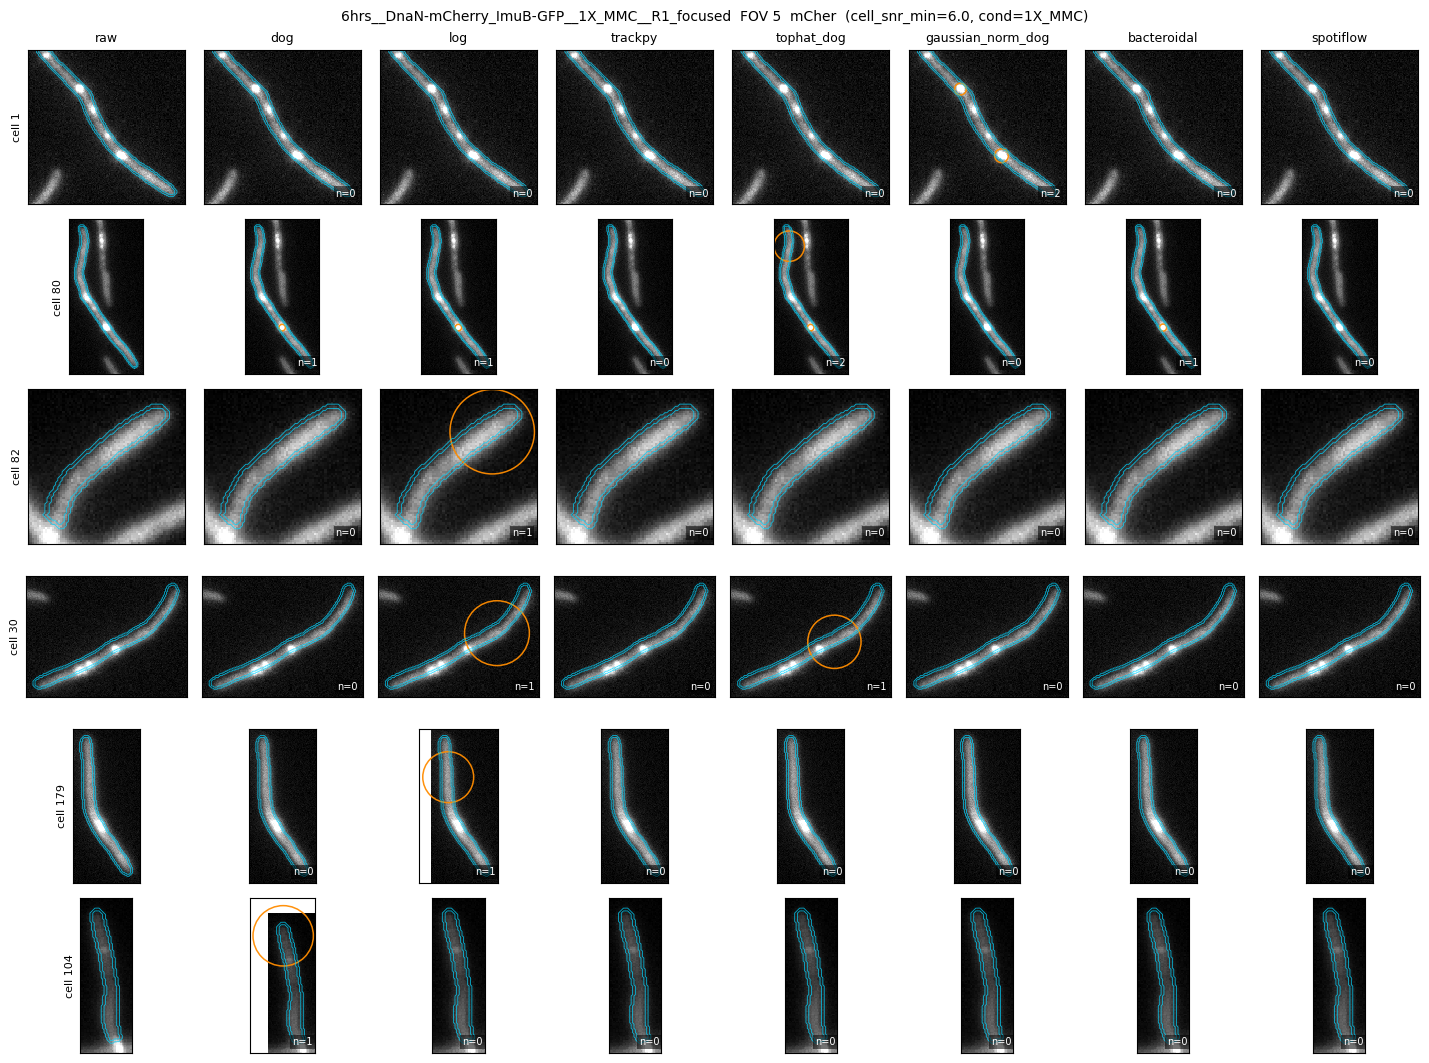

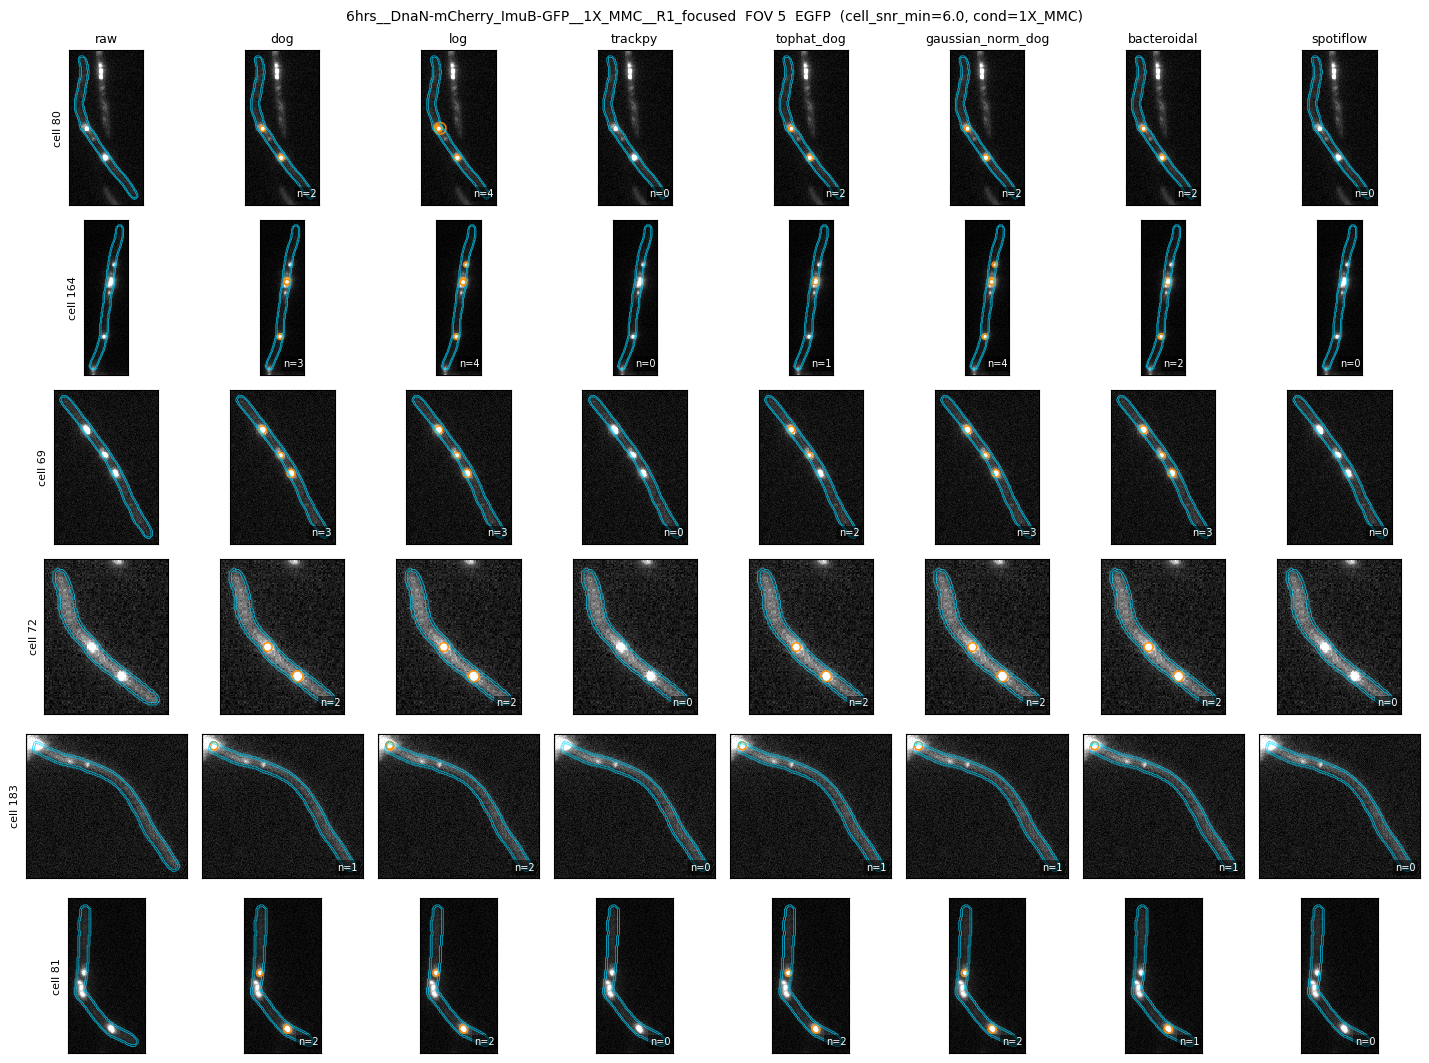

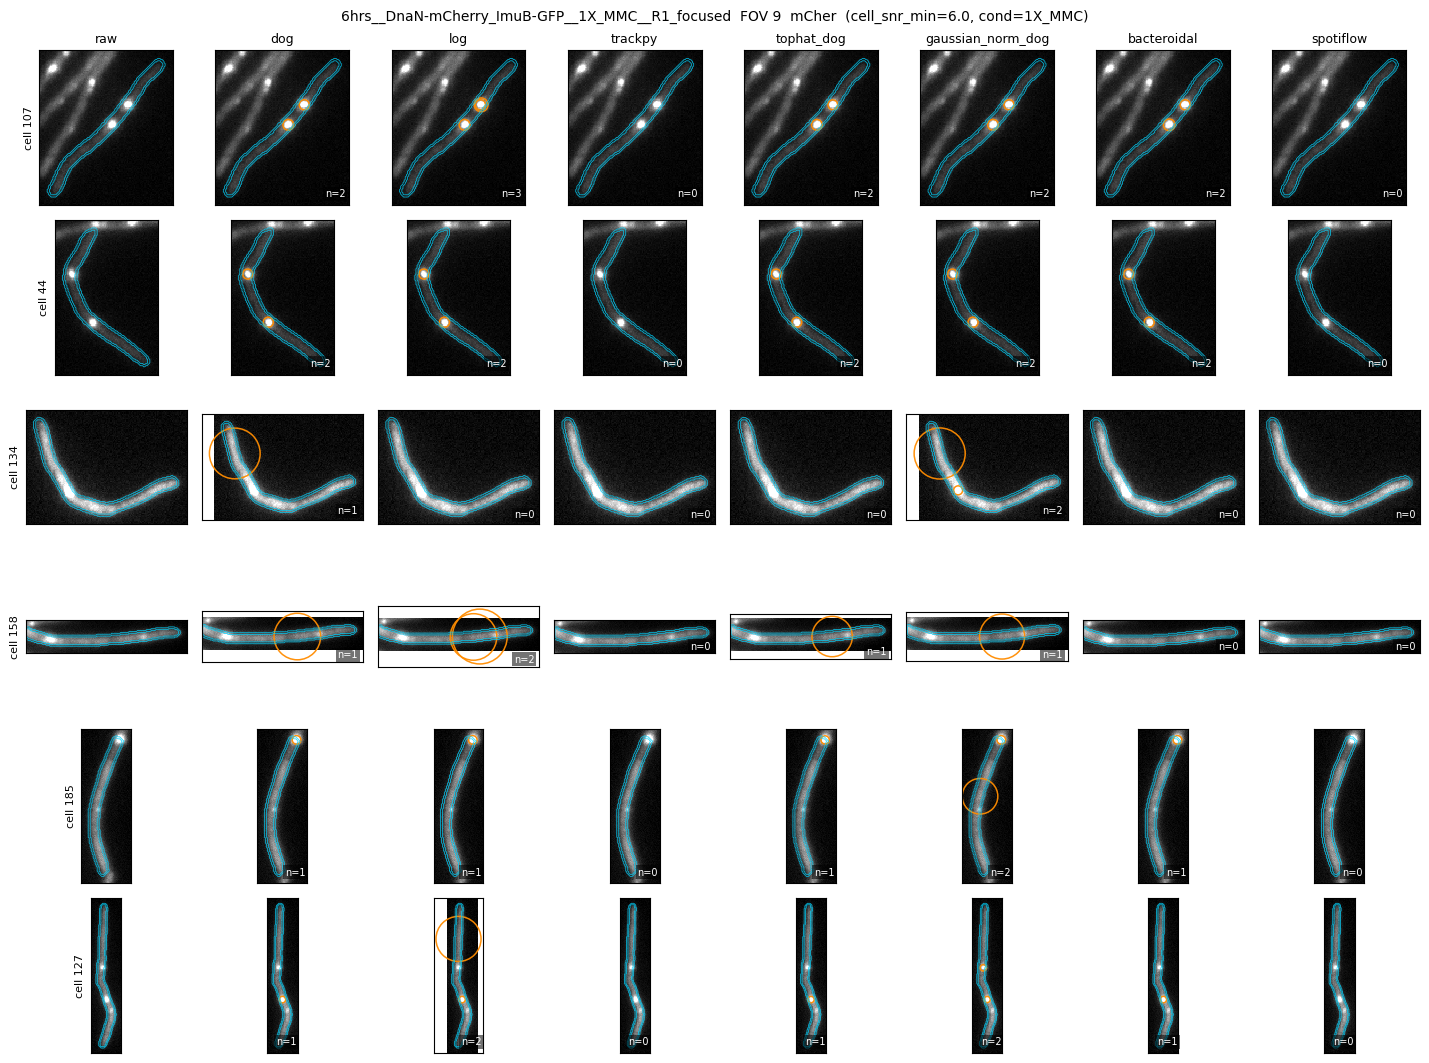

Saved filtered cell-crop grids to /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/foci_benchmark_outputs/Test__20260516_094437/cell_crops_filtered


In [10]:
# Per-cell SNR filter — reject foci that don't sufficiently exceed each cell's
# OWN median + std. Compares to whole-cell background (not just an annulus),
# which is the right metric for bacterial foci where the cell is small.

import importlib
from scripts.benchmark_foci import metrics as bf_metrics
from scripts.benchmark_foci import viz as bf_viz
importlib.reload(bf_metrics); importlib.reload(bf_viz)

CELL_SNR_MIN = 6.0     # Tune this: ~3 lets a lot through; ~5-6 is conservative; ~8+ very strict.

# Build the (well, fov, channel) -> (image, labeled_mask) lookup the filter needs.
bundles_by_key = {}
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        bundles_by_key[(b.well, b.fov_index, b.channel_names[ci])] = (
            b.image_channels[ci], b.labeled_mask,
        )

foci_cache_filtered = bf_metrics.filter_cache_by_cell_snr(
    foci_cache, bundles_by_key,
    cell_snr_min=CELL_SNR_MIN,
    foci_exclusion_radius_px=3.0,
    drop_outside_cells=True,
)

# Quick summary: how many foci survived per detector?
before = {}; after = {}
for key, by_det in foci_cache.items():
    for det, foci in by_det.items():
        before[det] = before.get(det, 0) + len(foci)
        after[det] = after.get(det, 0) + len(foci_cache_filtered[key][det])
print(f"cell_snr_min={CELL_SNR_MIN}: foci kept (before → after)")
for det in sorted(before):
    pct = 100 * after[det] / before[det] if before[det] else 0
    print(f"  {det:>20s}: {before[det]:5d} → {after[det]:5d}  ({pct:.1f}%)")

# Re-render the per-cell crop grids with the filtered cache
N_CELLS_PER_FOV = 6
SHOW_INLINE = 3
crops_out = OUT_DIR / "cell_crops_filtered"
crops_out.mkdir(exist_ok=True)
shown = 0
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        foci_by_det = foci_cache_filtered.get(key, {})
        cell_ids = bf_viz.select_interesting_cells(
            b.labeled_mask, foci_by_det, n=N_CELLS_PER_FOV,
        )
        if not cell_ids:
            continue
        fig = bf_viz.cell_crop_grid(
            b.image_channels[ci], b.labeled_mask, cell_ids, foci_by_det,
            pad_px=8, sigma_scale=2.0, panel_size=1.8,
            title=f"{b.well}  FOV {b.fov_index}  {cname}  "
                  f"(cell_snr_min={CELL_SNR_MIN}, cond={b.condition_fields.get('condition_label','')})",
        )
        fig.savefig(
            crops_out / f"{b.well}__fov{b.fov_index:03d}__{cname}.png",
            dpi=120, bbox_inches="tight",
        )
        if shown < SHOW_INLINE:
            plt.show(); shown += 1
        else:
            plt.close(fig)
print(f"Saved filtered cell-crop grids to {crops_out}")

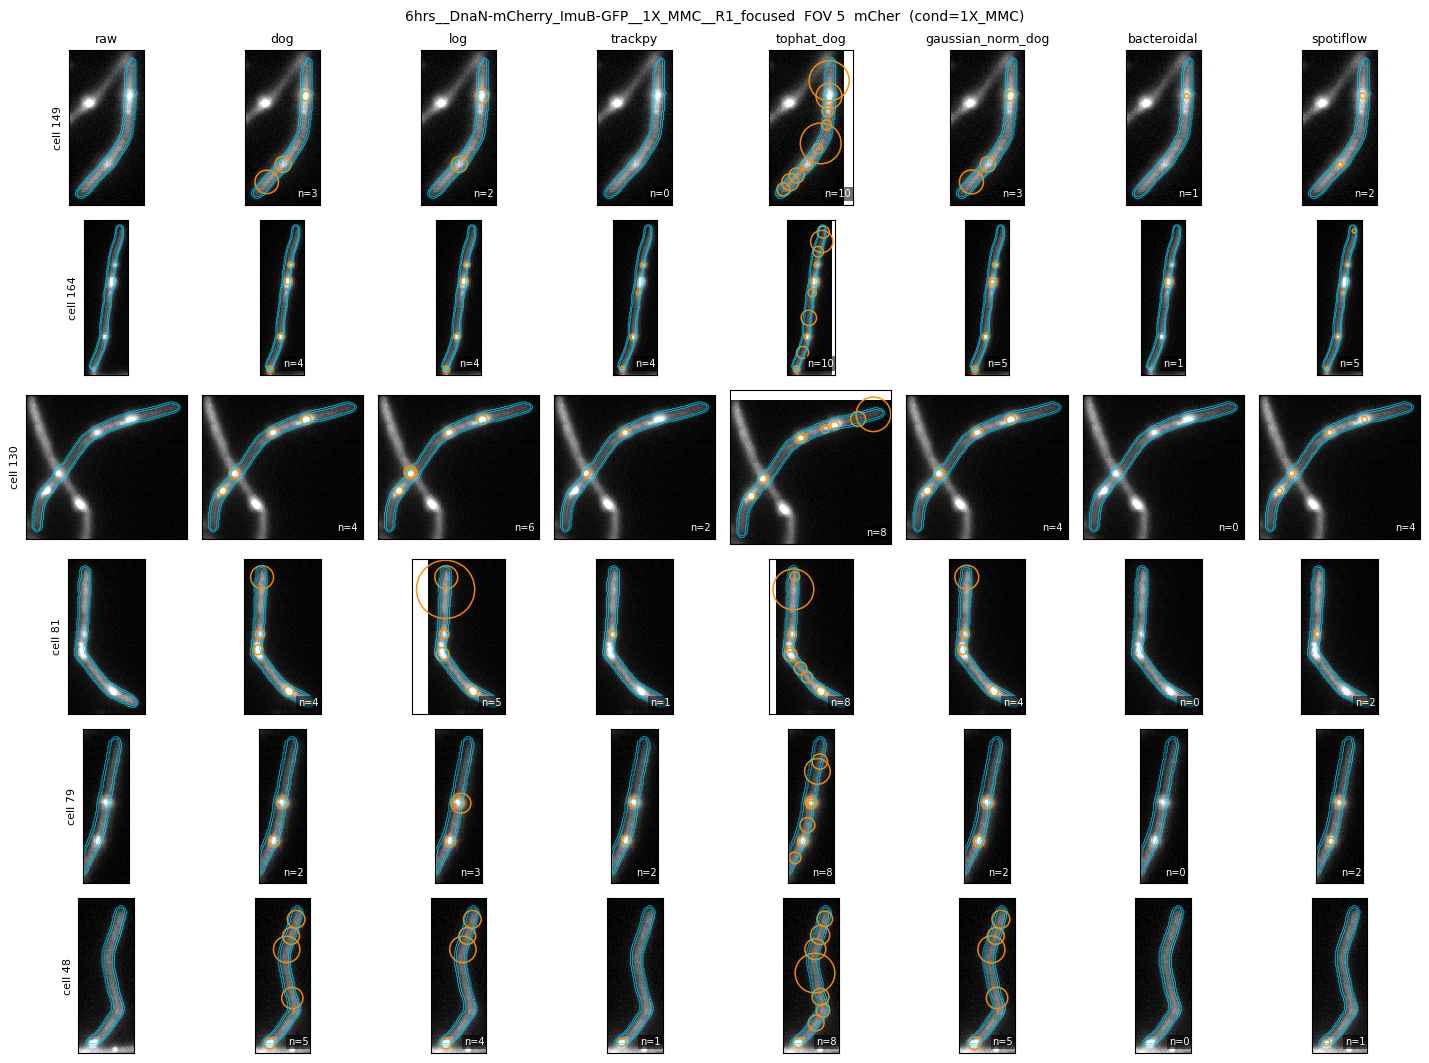

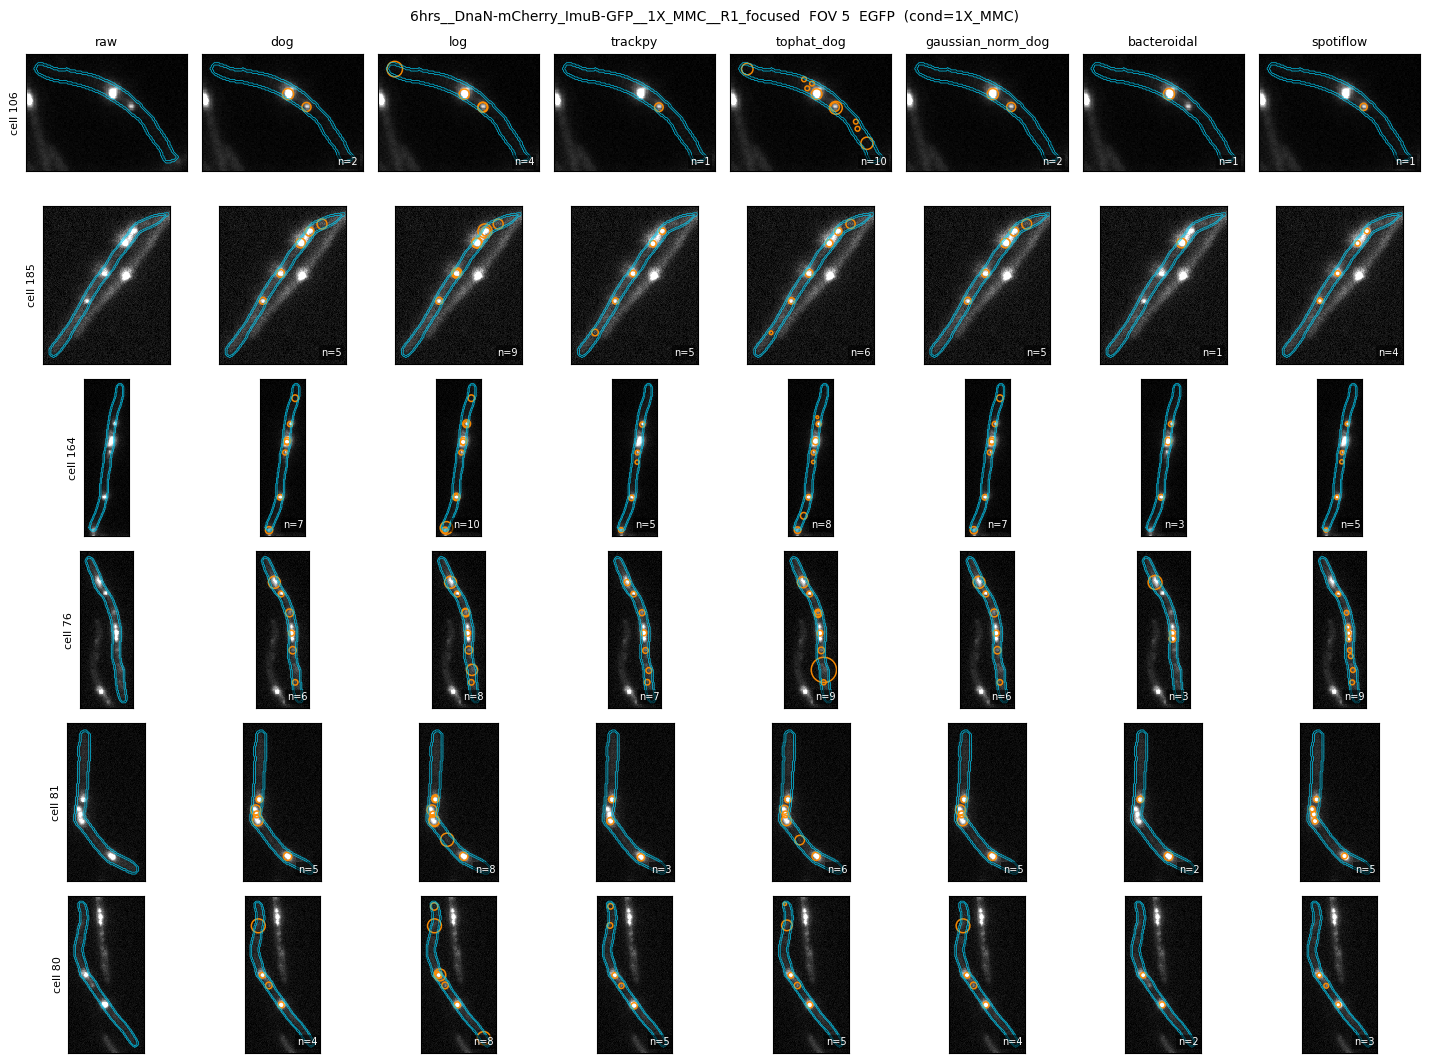

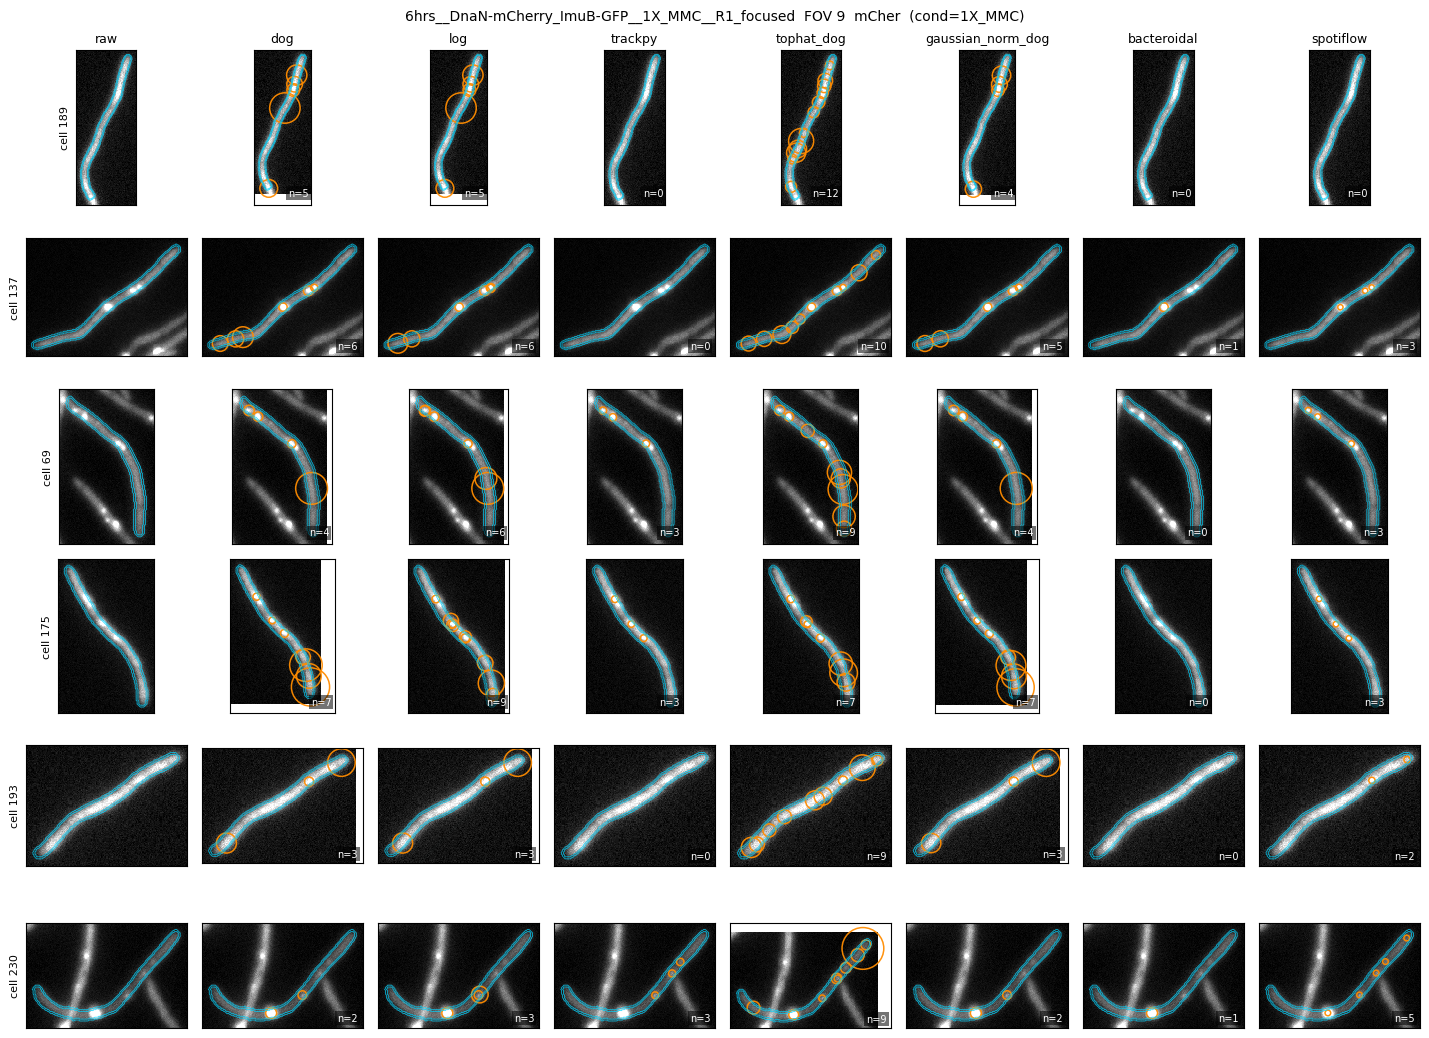

Saved 3 cell-crop comparison PNGs to /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/foci_benchmark_outputs/Test__20260516_094437/cell_crops


In [11]:
# Per-cell comparison grids (zoomed). Rows = cells, columns = raw + each detector.
# Selects cells where detectors disagree most, so you see the interesting cases first.

import importlib
from scripts.benchmark_foci import viz as bf_viz
importlib.reload(bf_viz)   # pick up the newly added functions

N_CELLS_PER_FOV = 6       # how many cells per FOV to show
SHOW_INLINE = 3           # also display the first N grids inline (0 = save only)
crops_out = OUT_DIR / "cell_crops"
crops_out.mkdir(exist_ok=True)

shown = 0
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        foci_by_det = foci_cache.get(key, {})
        if not foci_by_det:
            continue
        cell_ids = bf_viz.select_interesting_cells(
            b.labeled_mask, foci_by_det, n=N_CELLS_PER_FOV,
        )
        if not cell_ids:
            continue
        fig = bf_viz.cell_crop_grid(
            b.image_channels[ci], b.labeled_mask, cell_ids, foci_by_det,
            pad_px=8, sigma_scale=2.0, panel_size=1.8,
            title=f"{b.well}  FOV {b.fov_index}  {cname}  "
                  f"(cond={b.condition_fields.get('condition_label','')})",
        )
        fig.savefig(
            crops_out / f"{b.well}__fov{b.fov_index:03d}__{cname}.png",
            dpi=120, bbox_inches="tight",
        )
        if shown < SHOW_INLINE:
            plt.show(); shown += 1
        else:
            plt.close(fig)
print(f"Saved {shown if shown else 'all'} cell-crop comparison PNGs to {crops_out}")

In [12]:
%load_ext autoreload
%autoreload 2

Running wavelet on all FOV × channel ...
  done in 27.9s

Filters: σ ∈ (1.0, 2.5), cell_snr_min=4.0
              detector   raw → filtered   (% kept)
           bacteroidal:   432 →   262   (60.6%)
                   dog:  3984 →   266   (6.7%)
     gaussian_norm_dog:  4019 →   259   (6.4%)
                   log:  9889 →   283   (2.9%)
             spotiflow:  3131 →     0   (0.0%)
            tophat_dog: 11563 →   305   (2.6%)
               trackpy:  6916 →     0   (0.0%)
               wavelet: 19219 →   286   (1.5%)


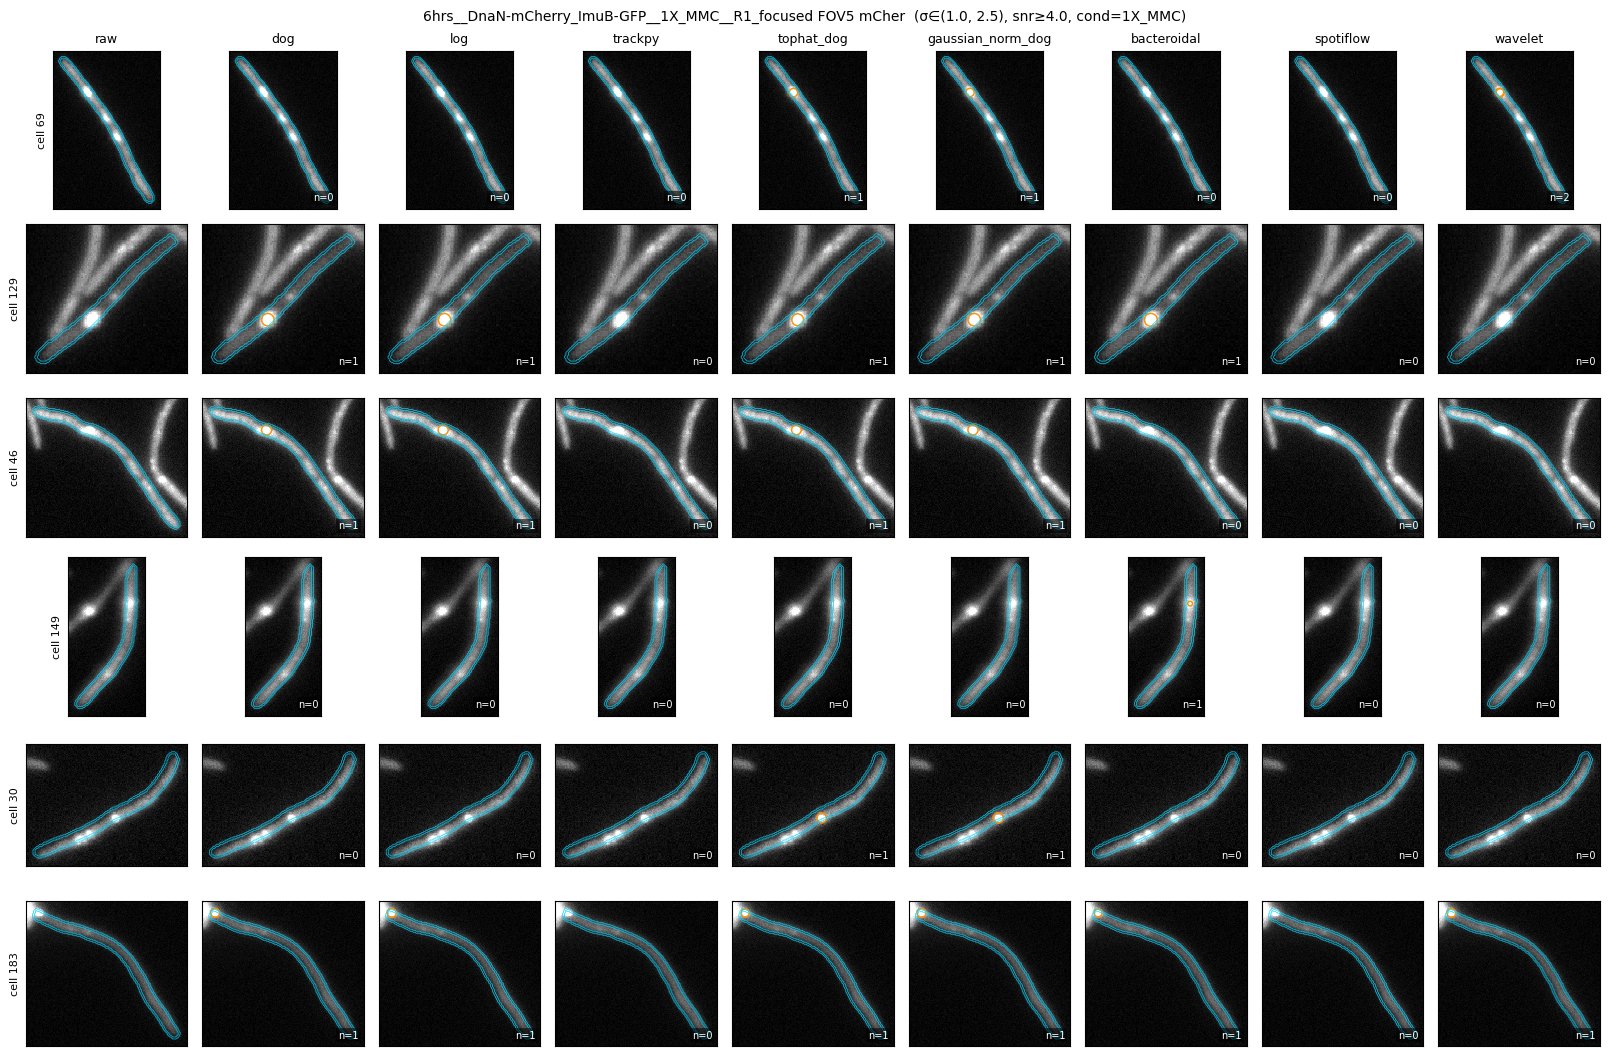

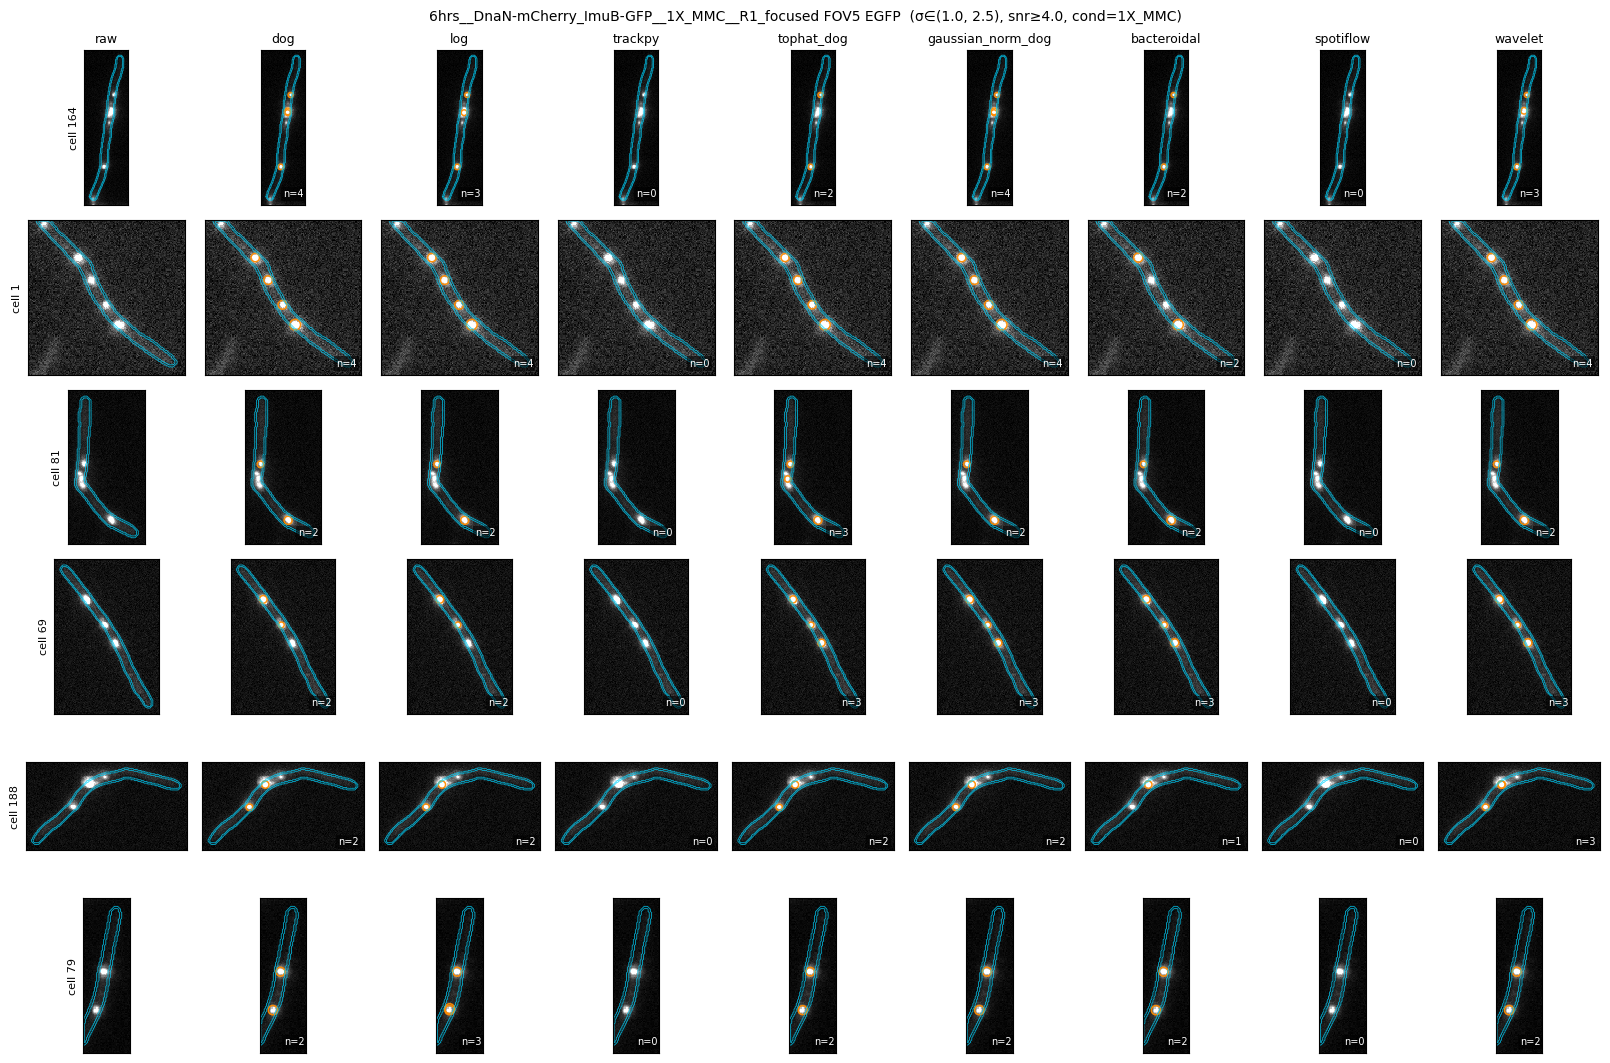

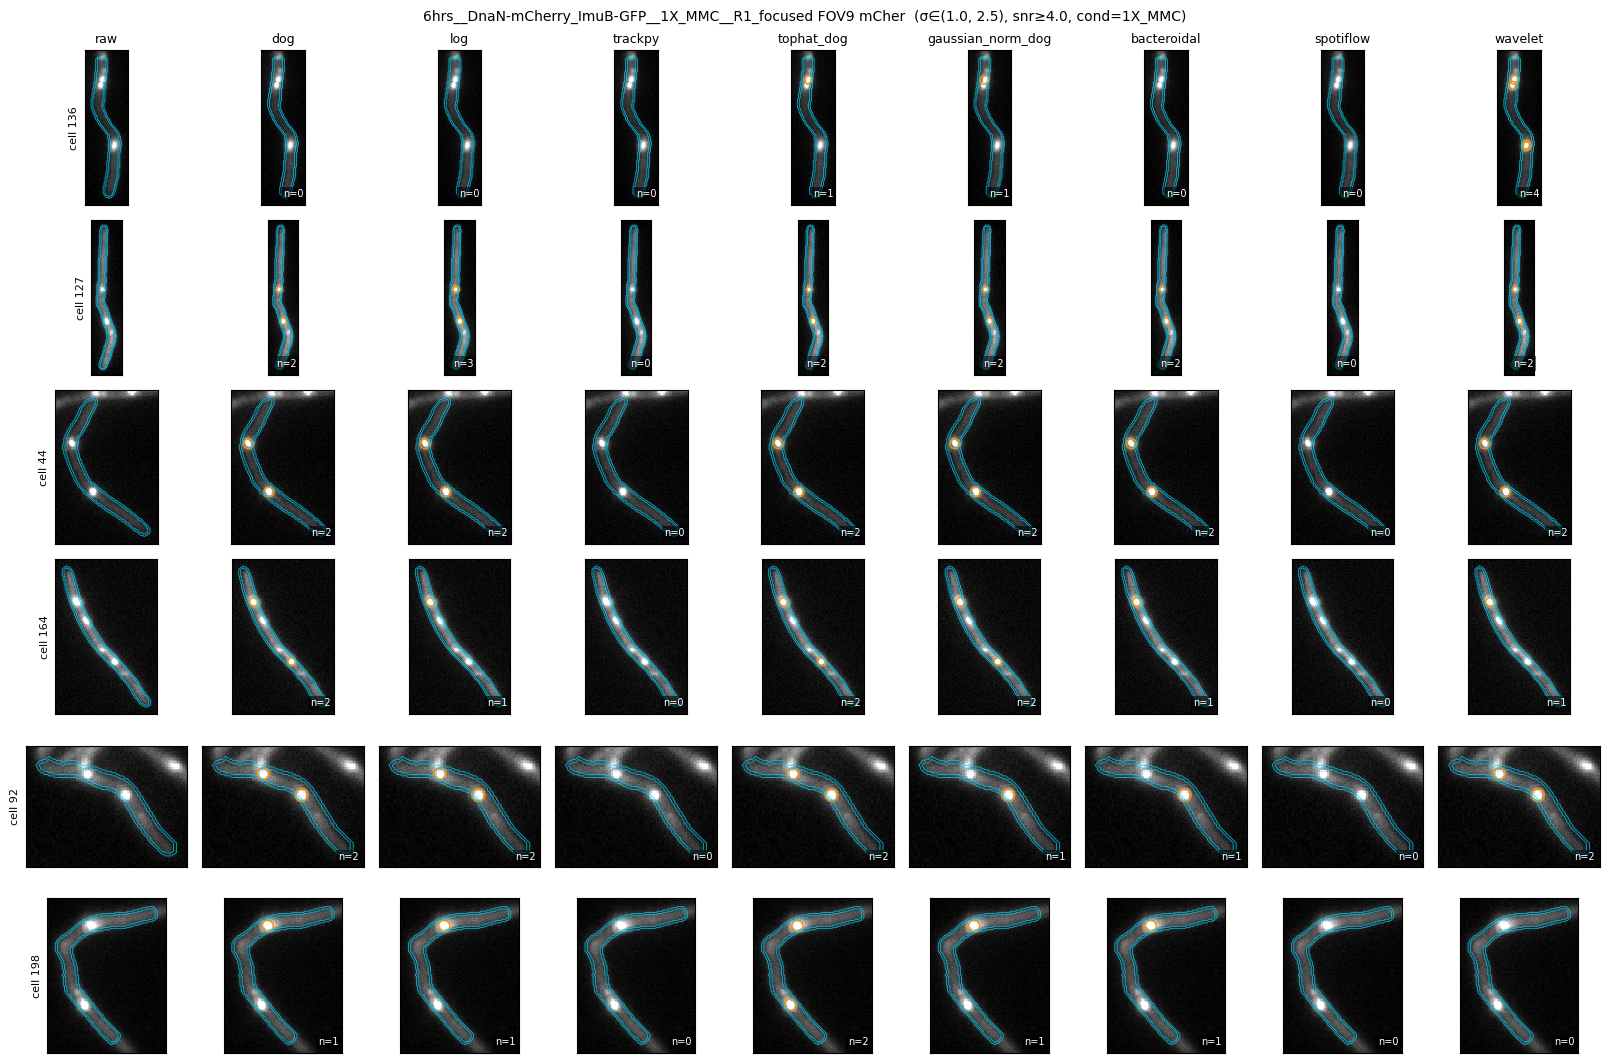


Saved cell-crop grids to /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/foci_benchmark_outputs/Test__20260516_094437/cell_crops_wavelet


In [13]:
# Add à trous wavelet detector + apply σ-range and per-cell SNR filters
# uniformly across every detector's results, then re-render per-cell crops.

import importlib, time
from scripts.benchmark_foci import detectors as bf_detectors
from scripts.benchmark_foci import metrics as bf_metrics
from scripts.benchmark_foci import viz as bf_viz
from scripts.benchmark_foci._types import DetectorOpts
importlib.reload(bf_detectors); importlib.reload(bf_metrics); importlib.reload(bf_viz)

# Wavelet-specific options. threshold_mad is the conservatism knob — bump higher if
# you still see false positives, lower if you're missing real dim foci.
OPTS_WAVELET = DetectorOpts(
    min_sigma=1.0, max_sigma=3.0, snr_min=0.0,
    wavelet_scales=(1, 2),
    wavelet_threshold_mad=4.0,        # ← tune this
    refine=True, refine_window=4,
)

wavelet_det = bf_detectors.WaveletAtrousDetector()
print("Running wavelet on all FOV × channel ...")
t0 = time.perf_counter()
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        foci = wavelet_det.detect(b.image_channels[ci],
                                  labeled_mask=b.labeled_mask, opts=OPTS_WAVELET)
        foci_cache[key]["wavelet"] = foci
print(f"  done in {time.perf_counter() - t0:.1f}s")

# Build (well, fov, channel) -> (image, mask) for the cache filter
bundles_by_key = {
    (b.well, b.fov_index, b.channel_names[ci]): (b.image_channels[ci], b.labeled_mask)
    for b in bundles for ci in b.fluorescence_channel_indices
}

# σ-range catches single-pixel salt noise (σ < 1) and broad cytoplasmic blobs (σ > 2.5).
# cell_snr_min rejects peaks that don't sufficiently exceed the cell's interior median.
SIGMA_RANGE = (1.0, 2.5)
CELL_SNR_MIN = 4.0
foci_cache_filtered = bf_metrics.filter_cache(
    foci_cache, bundles_by_key,
    sigma_min=SIGMA_RANGE[0], sigma_max=SIGMA_RANGE[1],
    cell_snr_min=CELL_SNR_MIN,
)

# Summary table
before = {}; after = {}
for key, by_det in foci_cache.items():
    for det, foci in by_det.items():
        before[det] = before.get(det, 0) + len(foci)
        after[det] = after.get(det, 0) + len(foci_cache_filtered[key][det])
print(f"\nFilters: σ ∈ {SIGMA_RANGE}, cell_snr_min={CELL_SNR_MIN}")
print(f"  {'detector':>20s}   raw → filtered   (% kept)")
for det in sorted(before):
    pct = 100 * after[det] / before[det] if before[det] else 0
    print(f"  {det:>20s}: {before[det]:5d} → {after[det]:5d}   ({pct:.1f}%)")

# Re-render per-cell crops with filtered cache
N_CELLS_PER_FOV = 6
SHOW_INLINE = 3
crops_out = OUT_DIR / "cell_crops_wavelet"
crops_out.mkdir(exist_ok=True)
shown = 0
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        foci_by_det = foci_cache_filtered.get(key, {})
        cell_ids = bf_viz.select_interesting_cells(b.labeled_mask, foci_by_det, n=N_CELLS_PER_FOV)
        if not cell_ids:
            continue
        fig = bf_viz.cell_crop_grid(
            b.image_channels[ci], b.labeled_mask, cell_ids, foci_by_det,
            pad_px=8, sigma_scale=2.0, panel_size=1.8,
            title=f"{b.well} FOV{b.fov_index} {cname}  "
                  f"(σ∈{SIGMA_RANGE}, snr≥{CELL_SNR_MIN}, "
                  f"cond={b.condition_fields.get('condition_label','')})",
        )
        fig.savefig(crops_out / f"{b.well}__fov{b.fov_index:03d}__{cname}.png",
                    dpi=120, bbox_inches="tight")
        if shown < SHOW_INLINE:
            plt.show(); shown += 1
        else:
            plt.close(fig)
print(f"\nSaved cell-crop grids to {crops_out}")

Running on 3/3 bundles (6 FOV-channel calls per detector)
           decon_wavelet:   75.3s  (43768 foci total)
            bm3d_wavelet:  324.6s  (46338 foci total)
      decon_bm3d_wavelet:  448.8s  (108883 foci total)

Filters: σ ∈ (1.0, 2.5), cell_snr_min=3.0  (on 6 FOV-channel pairs)
                detector   raw → filtered   (% kept)
             bacteroidal:   432 →   300   (69.4%)
            bm3d_wavelet: 46338 →   352   (0.8%)
      decon_bm3d_wavelet: 108883 →  1008   (0.9%)
           decon_wavelet: 43768 →  1102   (2.5%)
                     dog:  3984 →   321   (8.1%)
       gaussian_norm_dog:  4019 →   316   (7.9%)
                     log:  9889 →   344   (3.5%)
               spotiflow:  3131 →     0   (0.0%)
              tophat_dog: 11563 →   370   (3.2%)
                 trackpy:  6916 →     0   (0.0%)
                 wavelet: 19219 →   372   (1.9%)


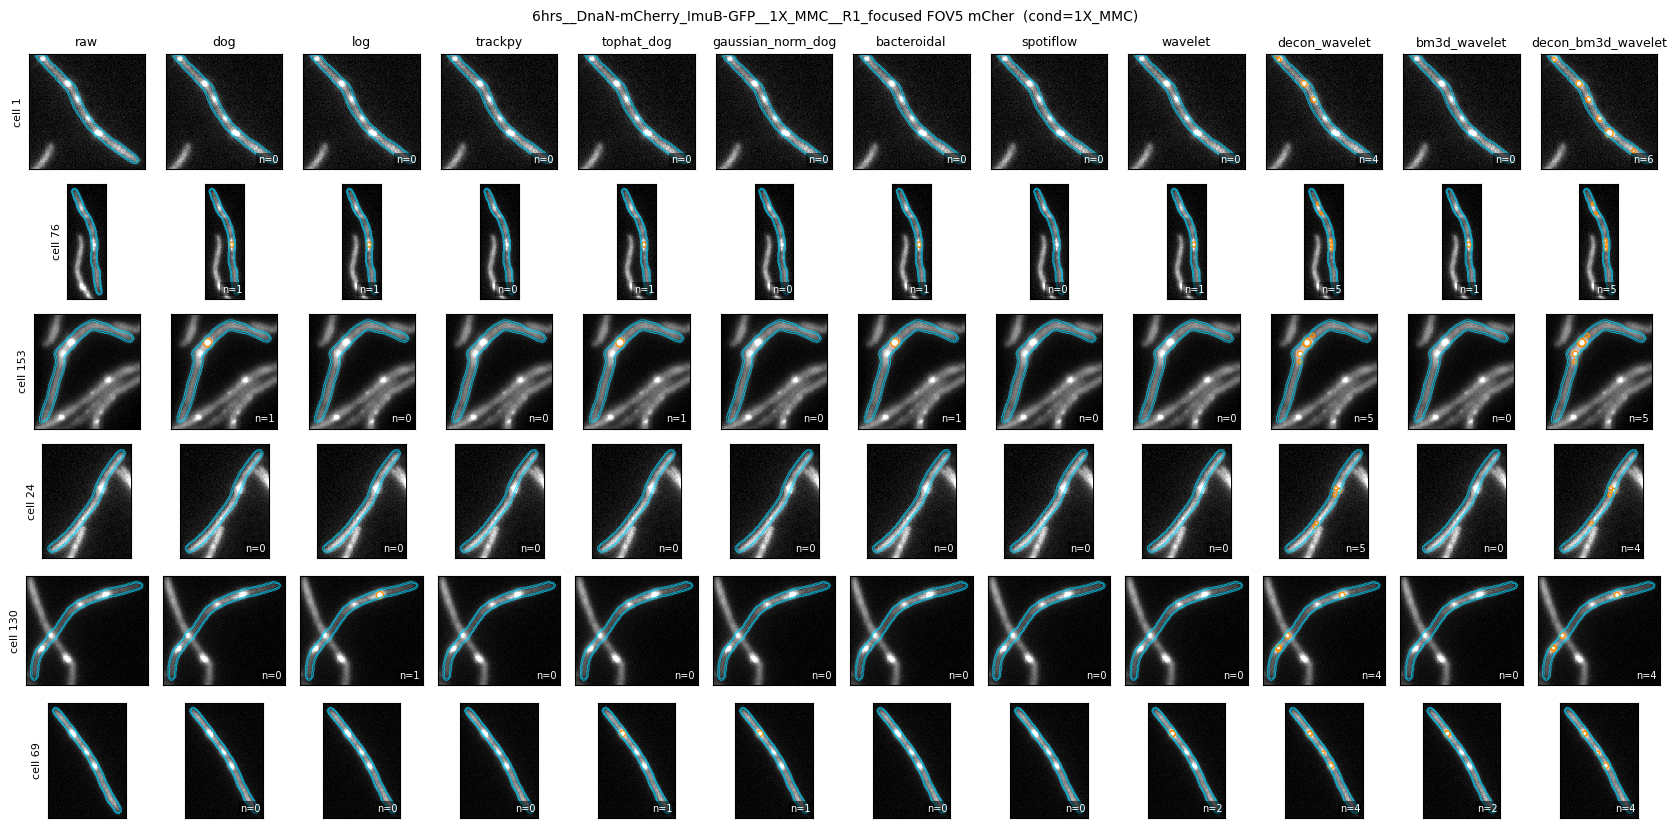

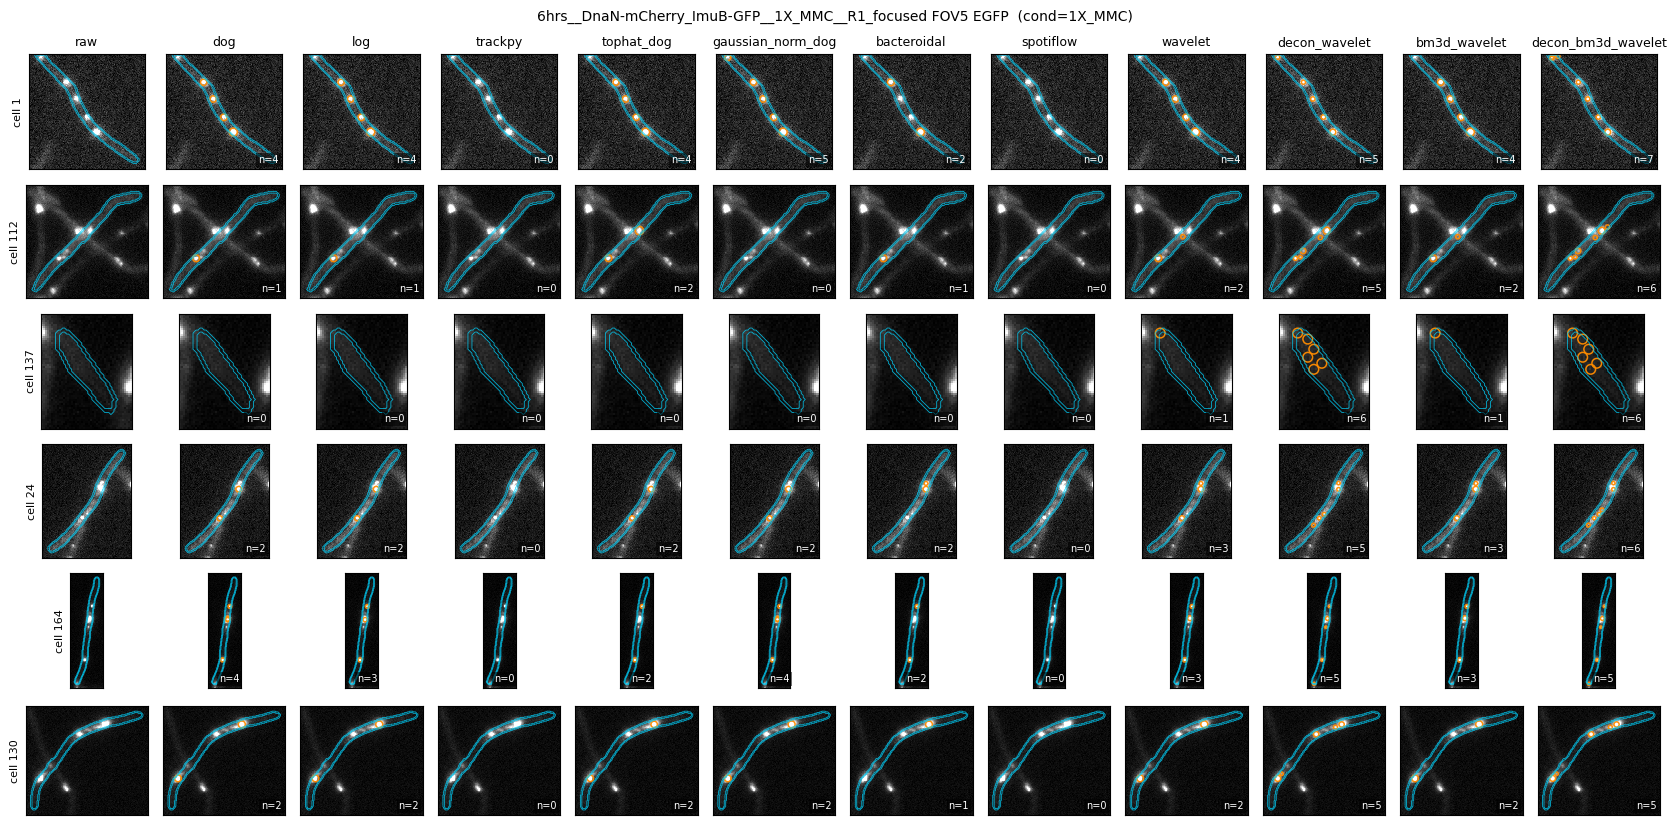

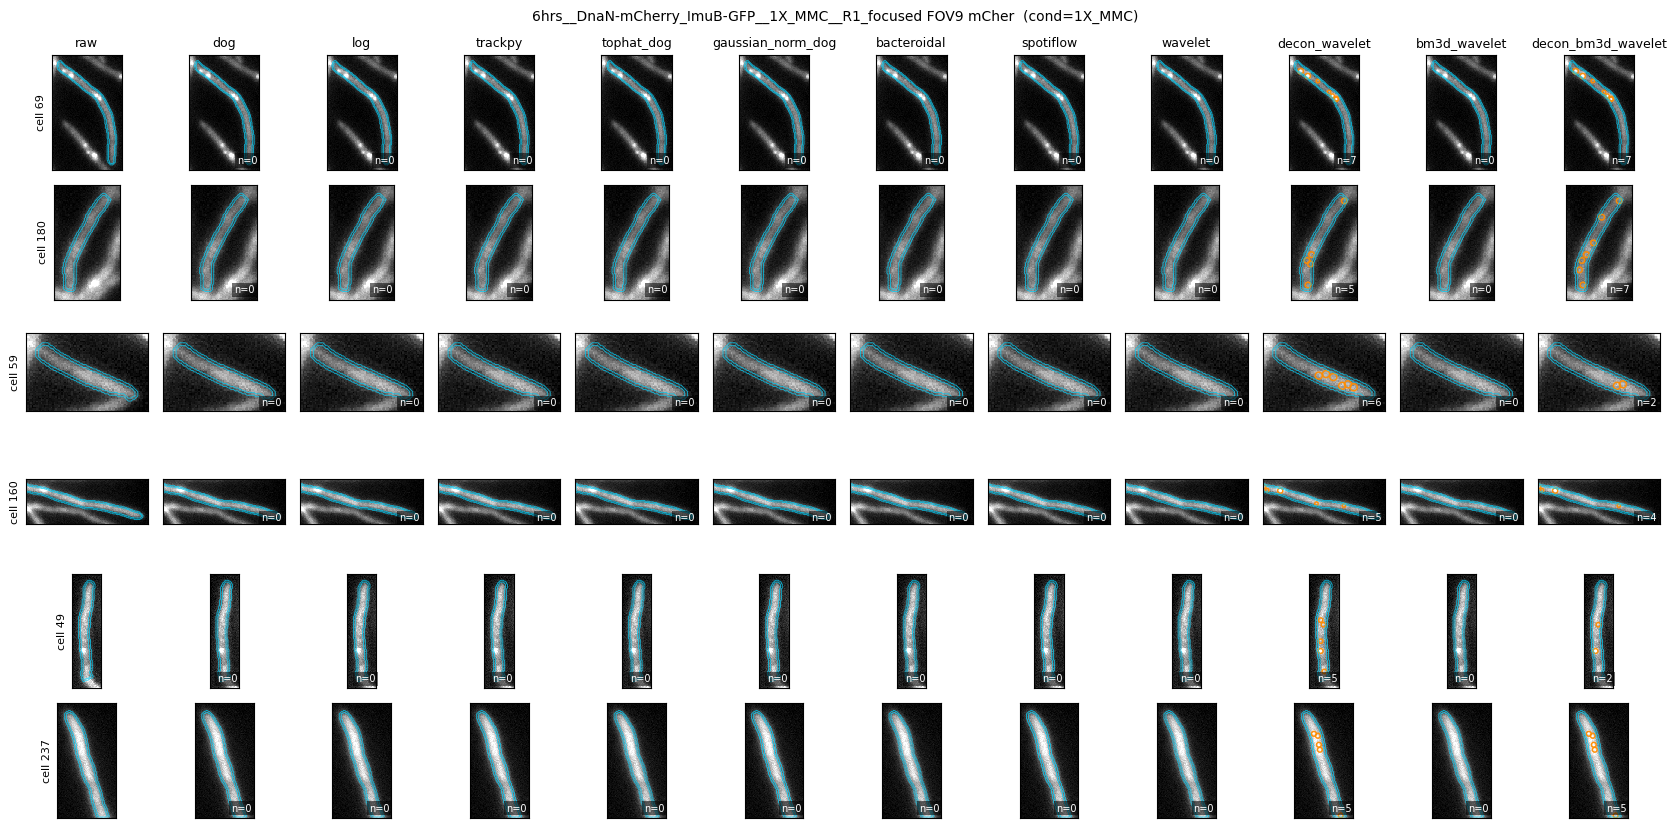


Saved cell-crop grids to /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/foci_benchmark_outputs/Test__20260516_094437/cell_crops_preprocessed


In [14]:
# Options B + C: Richardson-Lucy deconvolution and BM3D denoising as
# preprocessing in front of the wavelet detector. Runs new detectors on
# (a subset of) existing bundles and merges into foci_cache.

import time
from scripts.benchmark_foci import detectors as bf_detectors
from scripts.benchmark_foci import metrics as bf_metrics
from scripts.benchmark_foci import viz as bf_viz
from scripts.benchmark_foci import preprocess as bf_pp
from scripts.benchmark_foci._types import DetectorOpts

# BM3D is slow (~30-60s per 2K×2K image). Set to a small int (e.g. 2-3)
# to run on just that many bundles for a quick look; set to None to run
# all 12 bundles (~15-20 min total across the three enhanced detectors).
SUBSET_BUNDLES = 3      # ← try with 3 first; bump to None once it works

# Wavelet knob: after preprocessing the signal is cleaner, so a lower
# threshold often works. Try 2.5-3.0 first; bump up if too noisy.
OPTS_ENHANCED = DetectorOpts(
    min_sigma=1.0, max_sigma=3.0, snr_min=0.0,
    wavelet_scales=(1, 2),
    wavelet_threshold_mad=3.0,
    refine=True, refine_window=4,
)

new_detectors = {
    "decon_wavelet":       bf_detectors.DeconvolveWaveletDetector(iterations=30),
    "bm3d_wavelet":        bf_detectors.Bm3dWaveletDetector(),
    "decon_bm3d_wavelet":  bf_detectors.DeconvolveBm3dWaveletDetector(iterations=30),
}

run_bundles = bundles if SUBSET_BUNDLES is None else bundles[:SUBSET_BUNDLES]
print(f"Running on {len(run_bundles)}/{len(bundles)} bundles "
      f"({sum(len(b.fluorescence_channel_indices) for b in run_bundles)} FOV-channel calls per detector)")

for det_name, det in new_detectors.items():
    t0 = time.perf_counter()
    n_foci = 0
    for b in run_bundles:
        for ci in b.fluorescence_channel_indices:
            cname = b.channel_names[ci]
            key = (b.well, b.fov_index, cname)
            foci = det.detect(b.image_channels[ci],
                              labeled_mask=b.labeled_mask, opts=OPTS_ENHANCED)
            foci_cache[key][det_name] = foci
            n_foci += len(foci)
    print(f"  {det_name:>22s}: {time.perf_counter() - t0:6.1f}s  ({n_foci} foci total)")

# Apply σ-range + per-cell SNR filters uniformly
bundles_by_key = {
    (b.well, b.fov_index, b.channel_names[ci]): (b.image_channels[ci], b.labeled_mask)
    for b in run_bundles for ci in b.fluorescence_channel_indices
}
SIGMA_RANGE = (1.0, 2.5)
CELL_SNR_MIN = 3.0
foci_cache_filtered = bf_metrics.filter_cache(
    foci_cache, bundles_by_key,
    sigma_min=SIGMA_RANGE[0], sigma_max=SIGMA_RANGE[1],
    cell_snr_min=CELL_SNR_MIN,
)

# Counts before/after filtering — only consider the bundles we ran on
keys_ran = set(bundles_by_key.keys())
before = {}; after = {}
for key in keys_ran:
    for det, foci in foci_cache.get(key, {}).items():
        before[det] = before.get(det, 0) + len(foci)
        after[det] = after.get(det, 0) + len(foci_cache_filtered.get(key, {}).get(det, []))
print(f"\nFilters: σ ∈ {SIGMA_RANGE}, cell_snr_min={CELL_SNR_MIN}  (on {len(keys_ran)} FOV-channel pairs)")
print(f"  {'detector':>22s}   raw → filtered   (% kept)")
for det in sorted(before):
    pct = 100 * after[det] / before[det] if before[det] else 0
    print(f"  {det:>22s}: {before[det]:5d} → {after[det]:5d}   ({pct:.1f}%)")

# Re-render per-cell crop grids with the filtered cache
N_CELLS_PER_FOV = 6
SHOW_INLINE = 3
crops_out = OUT_DIR / "cell_crops_preprocessed"
crops_out.mkdir(exist_ok=True)
shown = 0
for b in run_bundles:
    for ci in b.fluorescence_channel_indices: 
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        foci_by_det = foci_cache_filtered.get(key, {})
        cell_ids = bf_viz.select_interesting_cells(b.labeled_mask, foci_by_det, n=N_CELLS_PER_FOV)
        if not cell_ids:
            continue
        fig = bf_viz.cell_crop_grid(
            b.image_channels[ci], b.labeled_mask, cell_ids, foci_by_det,
            pad_px=8, sigma_scale=2.0, panel_size=1.4,
            title=f"{b.well} FOV{b.fov_index} {cname}  "
                  f"(cond={b.condition_fields.get('condition_label','')})",
        )
        fig.savefig(crops_out / f"{b.well}__fov{b.fov_index:03d}__{cname}.png",
                    dpi=120, bbox_inches="tight")
        if shown < SHOW_INLINE:
            plt.show(); shown += 1
        else:
            plt.close(fig)
print(f"\nSaved cell-crop grids to {crops_out}")


Per-cell prominence sweep on 'decon_bm3d_wavelet':
  (σ ∈ (1.0, 2.5), cell_snr_min=3.0, baseline=cell p90)

  ratio   foci kept (over 6 FOV-channel pairs)
    1.0   1008
    1.3   981
    1.5   880
    1.8   753
    2.2   629


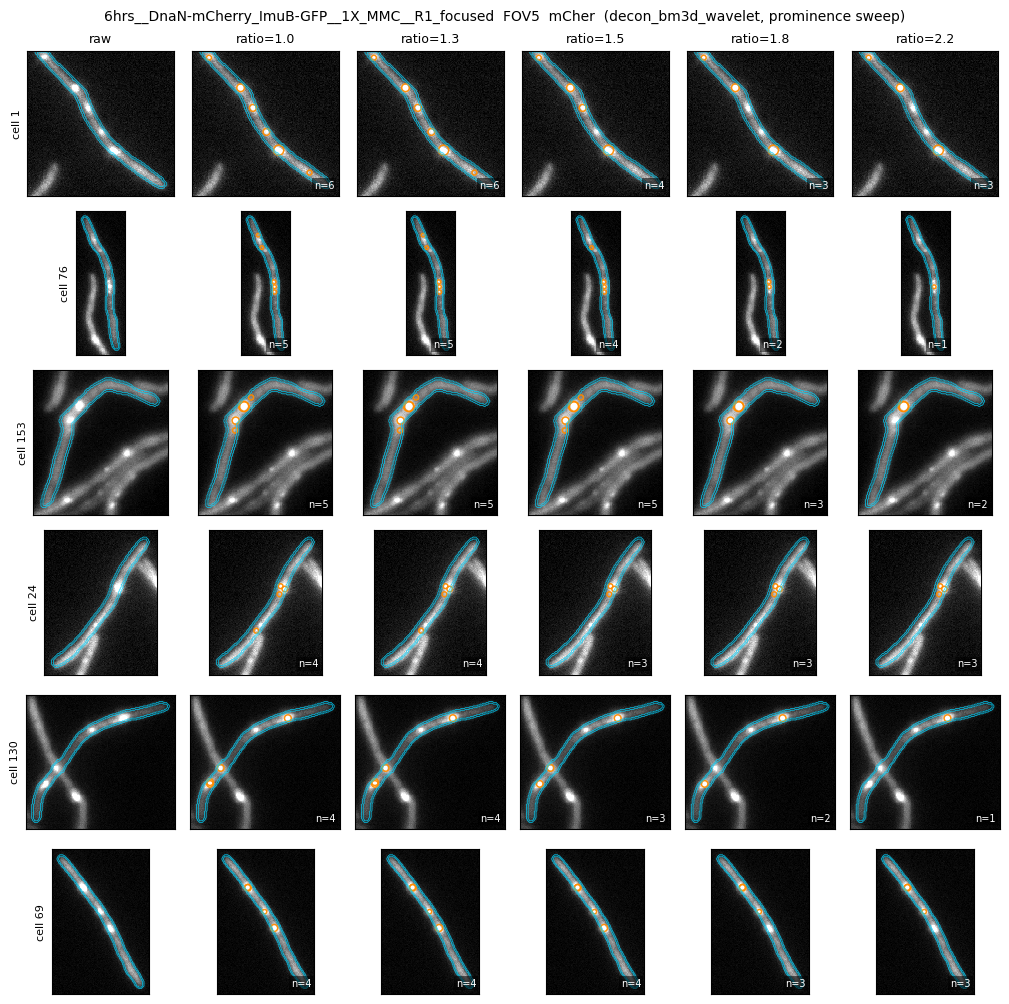

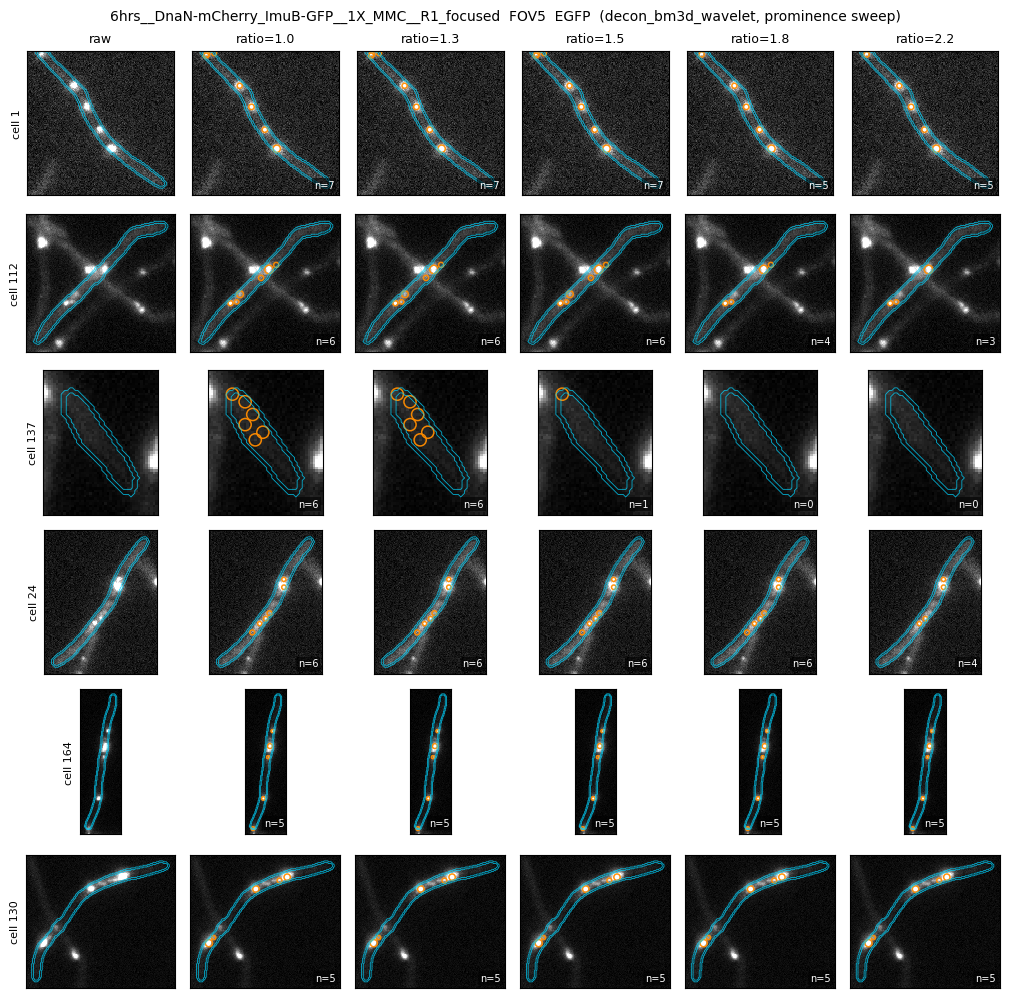


Saved prominence-sweep grids to /Users/timdewet/Library/CloudStorage/Dropbox-MMRU/Network Data/Microscopy/Tim/2026/DNA_Array/MMC_Conc/processed/03_classify/foci_benchmark_outputs/Test__20260516_094437/prominence_sweep


In [15]:
# Apply per-cell prominence filter to decon_bm3d_wavelet (and others).
# Sweeps PROMINENCE_RATIO so you can pick the value that matches your eye.

import importlib
from scripts.benchmark_foci import metrics as bf_metrics
from scripts.benchmark_foci import viz as bf_viz
importlib.reload(bf_metrics); importlib.reload(bf_viz)

# ─── Filter knobs ───
SIGMA_RANGE        = (1.0, 2.5)
CELL_SNR_MIN       = 3.0
PROMINENCE_RATIOS  = [1.0, 1.3, 1.5, 1.8, 2.2]    # 1.0 = no prominence filter
FOCUS_DETECTOR     = "decon_bm3d_wavelet"          # which detector to visualize

# Counts sweep
print(f"\nPer-cell prominence sweep on '{FOCUS_DETECTOR}':")
print(f"  (σ ∈ {SIGMA_RANGE}, cell_snr_min={CELL_SNR_MIN}, baseline=cell p90)\n")
print(f"  {'ratio':>5}   foci kept (over {len(bundles_by_key)} FOV-channel pairs)")

cache_by_ratio = {}
for ratio in PROMINENCE_RATIOS:
    cache = bf_metrics.filter_cache(
        foci_cache, bundles_by_key,
        sigma_min=SIGMA_RANGE[0], sigma_max=SIGMA_RANGE[1],
        cell_snr_min=CELL_SNR_MIN,
        prominence_ratio=ratio,
        baseline_percentile=90.0,
    )
    cache_by_ratio[ratio] = cache

    n_kept = sum(
        len(cache[key].get(FOCUS_DETECTOR, []))
        for key in bundles_by_key
        if key in cache
    )
    print(f"  {ratio:>5.1f}   {n_kept}")

# Pick a couple of FOVs and render crops side-by-side across ratios for FOCUS_DETECTOR
# (rows = cells, columns = raw + each ratio).
N_FOVS_TO_SHOW = 2
N_CELLS_PER_FOV = 6

bundles_in_run = [b for b in bundles
                  if (b.well, b.fov_index, b.channel_names[b.fluorescence_channel_indices[0]]) in bundles_by_key]
shown = 0
crops_out = OUT_DIR / "prominence_sweep"
crops_out.mkdir(exist_ok=True)
for b in bundles_in_run:
    if shown >= N_FOVS_TO_SHOW:
        break
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        # Use the largest-ratio cache to pick "interesting" cells (most disagreement)
        ref_cache = cache_by_ratio[PROMINENCE_RATIOS[0]]
        cell_ids = bf_viz.select_interesting_cells(
            b.labeled_mask, ref_cache.get(key, {}), n=N_CELLS_PER_FOV,
        )
        if not cell_ids:
            continue

        # Build a {label_for_column: list[Focus]} dict where each "detector"
        # is actually one prominence-ratio variant of FOCUS_DETECTOR.
        foci_by_ratio_label = {
            f"ratio={r:.1f}": cache_by_ratio[r][key].get(FOCUS_DETECTOR, [])
            for r in PROMINENCE_RATIOS
        }
        fig = bf_viz.cell_crop_grid(
            b.image_channels[ci], b.labeled_mask, cell_ids, foci_by_ratio_label,
            pad_px=8, sigma_scale=2.0, panel_size=1.7,
            title=f"{b.well}  FOV{b.fov_index}  {cname}  ({FOCUS_DETECTOR}, prominence sweep)",
        )
        fig.savefig(crops_out / f"{b.well}__fov{b.fov_index:03d}__{cname}.png",
                    dpi=120, bbox_inches="tight")
        plt.show()
        shown += 1
        if shown >= N_FOVS_TO_SHOW:
            break 
print(f"\nSaved prominence-sweep grids to {crops_out}")

Stage 1: permissive proposals on all FOV × channel ...
  126338 proposals total in 215.6s (mean 21056 per FOV-channel)

Computing features for every proposal ...
  done in 249.9s  (126338 rows)


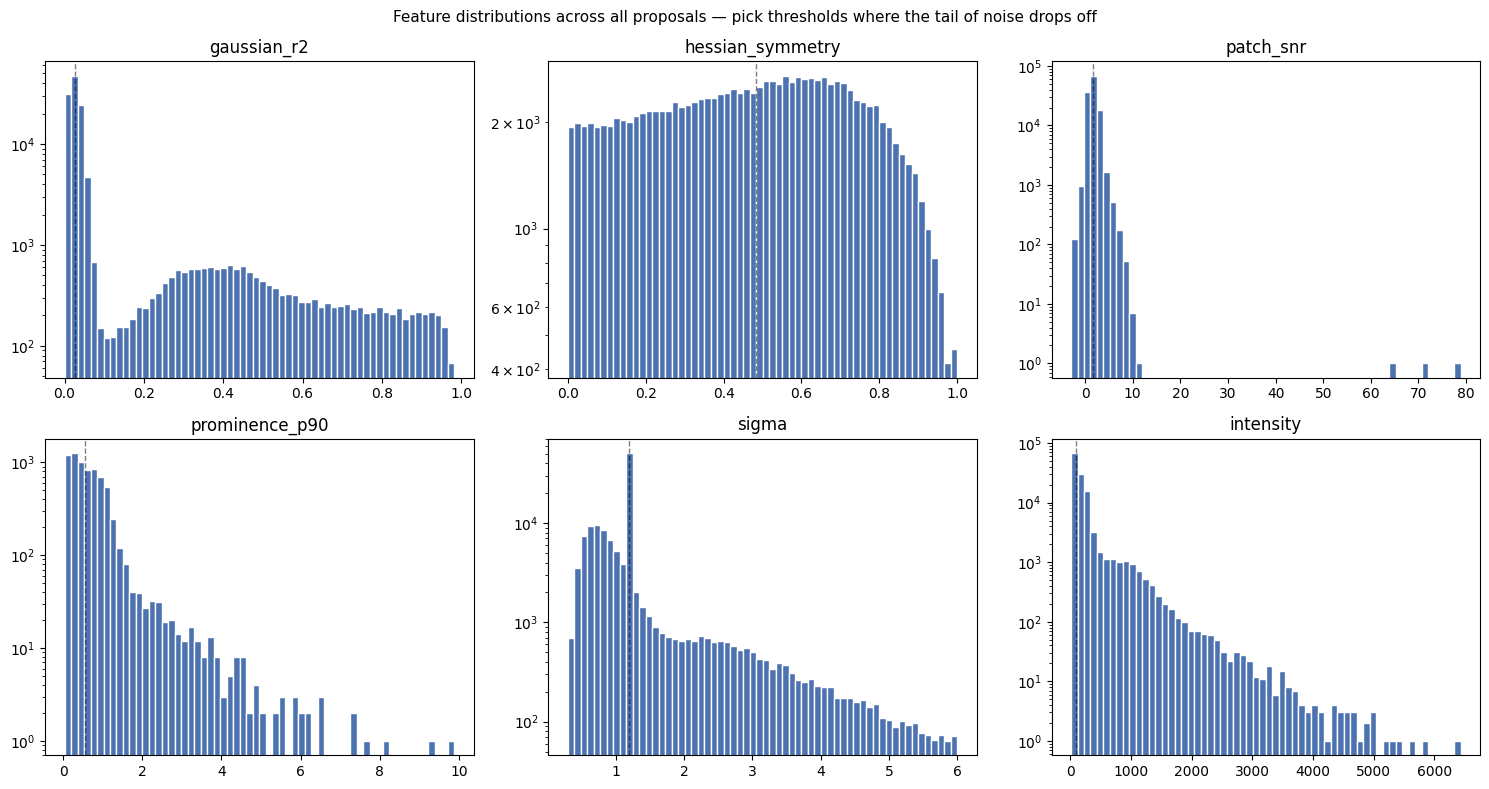


Rule-based filter:  126338 → 5826  (4.6% kept)

Foci per (condition, channel) after filtering:
condition_label  channel
1X_MMC           EGFP       3075
                 mCher      2751


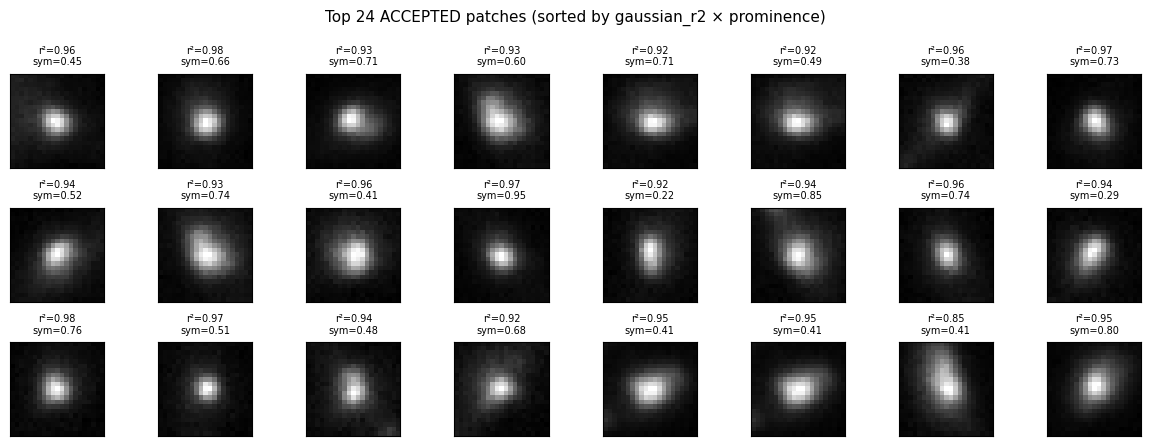

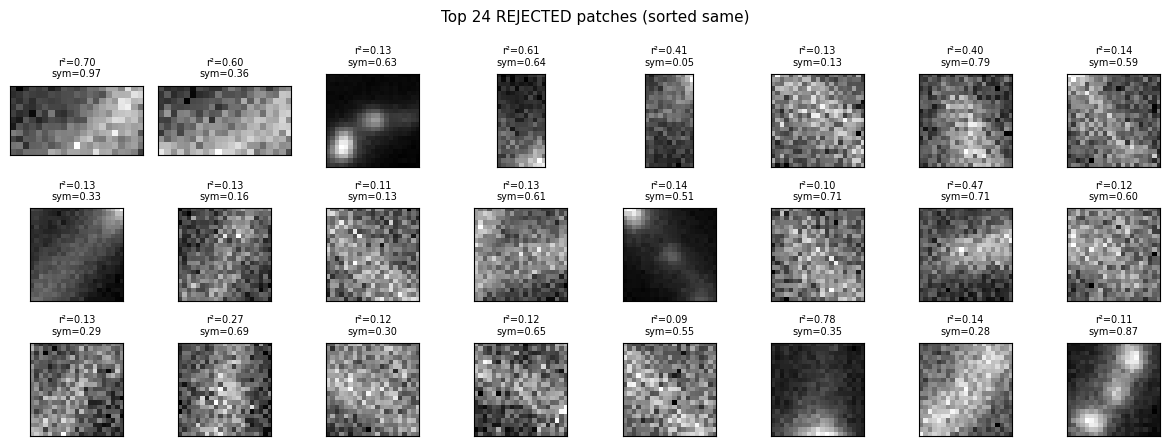

In [17]:
# Two-stage: high-recall detection → multi-feature classification.
# Stage 1: permissive gaussian_norm_wavelet → many candidates
# Stage 2a (this cell): visualize feature distributions + apply rule-based filter
# Stage 2b (next cell, optional): train a classifier on labeled patches

import time
from scripts.benchmark_foci import detectors as bf_detectors
from scripts.benchmark_foci import features as bf_features
from scripts.benchmark_foci import viz as bf_viz
from scripts.benchmark_foci._types import DetectorOpts

# ─── Stage 1: permissive detection ───
OPTS_PERMISSIVE = DetectorOpts(
    min_sigma=0.8, max_sigma=4.0, snr_min=0.0,         # wider σ net
    wavelet_scales=(1, 2),
    wavelet_threshold_mad=2.0,                          # ← permissive
    refine=True, refine_window=4,
)

det = bf_detectors.GaussianNormWaveletDetector()
proposals = {}        # {(well, fov, channel): list[Focus]}

print("Stage 1: permissive proposals on all FOV × channel ...")
t0 = time.perf_counter()
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        proposals[key] = det.detect(
            b.image_channels[ci],
            labeled_mask=b.labeled_mask,
            opts=OPTS_PERMISSIVE,
        )
n_total = sum(len(v) for v in proposals.values())
print(f"  {n_total} proposals total in {time.perf_counter()-t0:.1f}s "
      f"(mean {n_total/len(proposals):.0f} per FOV-channel)")

# ─── Stage 2: features for every proposal ───
print("\nComputing features for every proposal ...")
t0 = time.perf_counter()
feature_dfs = []
for b in bundles:
    for ci in b.fluorescence_channel_indices:
        cname = b.channel_names[ci]
        key = (b.well, b.fov_index, cname)
        df = bf_features.features_dataframe(
            b.image_channels[ci], b.labeled_mask, proposals[key],
            patch_half_size=8,
            detector="gaussian_norm_wavelet",
            well=b.well, fov_index=b.fov_index, channel=cname,
        )
        df["condition_label"] = b.condition_fields.get("condition_label", "")
        feature_dfs.append(df)
features_df = pd.concat(feature_dfs, ignore_index=True)
features_df.to_parquet(OUT_DIR / "proposals_features.parquet", index=False)
print(f"  done in {time.perf_counter()-t0:.1f}s  ({len(features_df)} rows)")

# ─── Inspect feature distributions ───
import matplotlib.pyplot as plt
key_features = ["gaussian_r2", "hessian_symmetry", "patch_snr",
                "prominence_p90", "sigma", "intensity"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, key_features):
    vals = features_df[feat].dropna().to_numpy()
    if len(vals) == 0:
        ax.set_title(f"{feat} — no data"); continue
    ax.hist(vals, bins=60, color="#4c72b0", edgecolor="white")
    ax.set_title(feat)
    ax.set_yscale("log")
    ax.axvline(np.median(vals), color="black", linestyle="--", linewidth=1, alpha=0.5)
fig.suptitle("Feature distributions across all proposals — pick thresholds where the tail of noise drops off", fontsize=11)
fig.tight_layout()
plt.show()

# ─── Apply rule-based filter ───
# Defaults from synthetic-data validation; tune by reading the histograms above.
RULES = {
    "gaussian_r2":     ("≥", 0.15),    # rejects salt noise + pure noise
    "hessian_symmetry":("≥", 0),    # rejects streaks / edges
    "patch_snr":       ("≥", 0),    # rejects diffuse blobs
    "sigma":           ("∈", (0, 6)),
    "prominence_p90":  ("≥", 0),    # rejects empty-cell false positives
}

def apply_rules(df, rules):
    keep = pd.Series(True, index=df.index)
    for feat, rule in rules.items():
        op, val = rule
        if op == "≥":
            keep &= df[feat].fillna(-np.inf) >= val
        elif op == "≤":
            keep &= df[feat].fillna(np.inf)  <= val
        elif op == "∈":
            lo, hi = val
            keep &= df[feat].between(lo, hi)
    return keep

mask_keep = apply_rules(features_df, RULES)
features_kept = features_df[mask_keep].copy()
print(f"\nRule-based filter:  {len(features_df)} → {len(features_kept)}  "
      f"({100*len(features_kept)/max(1,len(features_df)):.1f}% kept)")

# Per-detector / per-condition breakdown
print("\nFoci per (condition, channel) after filtering:")
print(features_kept.groupby(["condition_label", "channel"]).size().to_string())

# ─── Visualize accepted vs rejected patches ───
# Top-N rejected and accepted patches, side-by-side, for visual sanity check
from matplotlib.patches import Rectangle

def show_patch_montage(features_subset, title, n=24):
    n = min(n, len(features_subset))
    if n == 0:
        return
    cols = 8; rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = np.atleast_2d(axes)
    for i, (idx, row) in enumerate(features_subset.head(n).iterrows()):
        # Find the image for this proposal
        key = (row["well"], int(row["fov_index"]), row["channel"])
        image, _ = bundles_by_key[key]
        focus = bf_features.Focus(y=row["y"], x=row["x"], sigma=row["sigma"],
                                  intensity=row["intensity"], snr=row["snr_annulus"],
                                  cell_label=int(row["cell_label"]))
        patch, _ = bf_features.extract_patch(image, focus, half_size=10)
        ax = axes[i // cols, i % cols]
        ax.imshow(patch, cmap="gray")
        ax.set_title(f"r²={row['gaussian_r2']:.2f}\nsym={row['hessian_symmetry']:.2f}", fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
    for j in range(n, rows * cols):
        axes[j // cols, j % cols].axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()

# Highest-confidence accepted (top by gaussian_r2 × prominence_p90)
features_kept["_score"] = features_kept["gaussian_r2"] * features_kept["prominence_p90"]
features_kept = features_kept.sort_values("_score", ascending=False)
features_rejected = features_df[~mask_keep].copy()
features_rejected["_score"] = features_rejected["gaussian_r2"] * features_rejected["prominence_p90"].fillna(0)
features_rejected = features_rejected.sort_values("_score", ascending=False)

show_patch_montage(features_kept,    "Top 24 ACCEPTED patches (sorted by gaussian_r2 × prominence)")
show_patch_montage(features_rejected, "Top 24 REJECTED patches (sorted same)")

## Runtime

Wall-clock per detector per FOV. Anything > ~60 s/FOV is a non-starter for a full-screen v1 build.

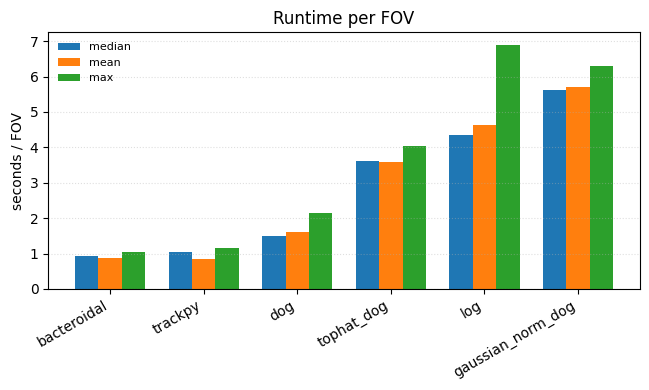

,median,mean,max
detector,,,
bacteroidal,0.939,0.880,1.046
dog,1.508,1.599,2.148
gaussian_norm_dog,5.610,5.694,6.304
log,4.345,4.632,6.905
tophat_dog,3.604,3.579,4.027
trackpy,1.031,0.855,1.151


In [16]:
fig = bf_viz.runtime_bar(runtime_df)
fig.savefig(OUT_DIR / "runtime_bar.png", dpi=120, bbox_inches="tight")
plt.show()

summary = runtime_df.groupby("detector")["seconds"].agg(["median", "mean", "max"]).round(3)
summary

## Summary table — counts per detector, split by condition

Quick at-a-glance: does the median foci/cell shift between control and damage conditions for each detector?

In [17]:
if not per_cell_df.empty:
    summary = (
        per_cell_df.groupby(["channel", "detector", "condition_label"])["foci_count"]
        .agg(["count", "mean", "median", "max"]).round(2)
    )
    summary.to_csv(OUT_DIR / "summary_by_condition.csv")
    summary

---

## Next steps after reviewing outputs

Once you've eyeballed `overlays/`, `count_distributions_*.png`, and `agreement_heatmap.png`:

1. Pick the detector with the best visual overlays + biggest control-vs-damage shift + acceptable runtime.
2. Note whether normalisation (`tophat_dog` or `gaussian_norm_dog`) changes counts substantially.
3. Feed those choices back — we then promote the winning detector(s) into `src/mycoprep/core/fluorescence/`
   and wire it into the Extract stage per the v1 plan.